# SGD Classifier - Online Batch Learning
Train SGDClassifier using year-based batches to simulate online learning scenario

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
import warnings

## 1. Load Prepared Data and Split

In [3]:
# Load the prepared dataset with features
ds_path = Path('.') / 'training_data_with_features_plus_monthly_indices.zarr'
print(f'Loading data from {ds_path}...')
ds = xr.open_dataset(ds_path, engine='zarr')
print('✓ Data loaded')

# Load the train/val/test split
split_path = Path('.') / 'data_split.npz'
print(f'\nLoading split from {split_path}...')
split_data = np.load(split_path)
train_pixel_indices = split_data['train_pixel_indices']
val_pixel_indices = split_data['val_pixel_indices']
test_pixel_indices = split_data['test_pixel_indices']
print('✓ Split loaded')

print(f'\nDataset info:')
print(f'  Total pixels: {len(ds.pixel)}')
print(f'  Total years: {len(ds.year)}')
print(f'  Train pixels: {len(train_pixel_indices)}')
print(f'  Val pixels: {len(val_pixel_indices)}')
print(f'  Test pixels: {len(test_pixel_indices)}')

Loading data from training_data_with_features_plus_monthly_indices.zarr...
✓ Data loaded

Loading split from data_split.npz...
✓ Split loaded

Dataset info:
  Total pixels: 8155205
  Total years: 7
  Train pixels: 5597776
  Val pixels: 1273437
  Test pixels: 1283992


## 2. Feature Engineering
Prepare features from S2 bands, spectral indices, DEM, and temporal deltas

In [4]:
def prepare_features_for_year(ds, pixel_indices, year_idx, scaler=None):
    """
    Extract and normalize features for a specific year and set of pixels.
    - Skips year 0 entirely (no features returned)
    - Fills S2 band NaNs with per-pixel mean across all years
    - Drops samples that still contain NaNs (e.g., pixels where all years are NaN)
    - Filters out invalid labels (keeps only 0 and 1, removes 255)
    - Adds temporal deltas starting from year 1 (2017), where year 1 delta = 2017 - 0
    
    Args:
        ds: xarray Dataset
        pixel_indices: array of pixel indices to extract
        year_idx: year index (0-based)
        scaler: StandardScaler instance (optional). If None, creates and fits a new one.
    
    Returns:
        X: normalized feature matrix (n_pixels, n_features)
        y: labels (n_pixels,)
        scaler: the scaler used (fitted if it was None)
    """
    # Skip year 0 entirely
    if year_idx == 0:
        return np.empty((0, 0)), np.empty((0,)), scaler

    # Precompute per-pixel S2 means across all years for imputation
    s2_all_years = ds['s2_bands'].isel(pixel=pixel_indices).values  # (pixels, year, band)
    s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)

    # Extract data for selected pixels and target year
    ds_subset = ds.isel(pixel=pixel_indices, year=year_idx)

    # S2 bands (flatten across bands)
    s2_features = ds_subset['s2_bands'].values  # (n_pixels, n_s2_bands)
    # Fill NaNs in S2 with per-pixel mean over years
    if np.isnan(s2_features).any():
        # broadcast mean to same shape and fill
        s2_features = np.where(np.isnan(s2_features), s2_mean_per_pixel, s2_features)

    # DEM
    dem_features = ds_subset['dem'].values.reshape(-1, 1)  # (n_pixels, 1)

    # Spectral indices
    ndvi_features = ds_subset['ndvi'].values.reshape(-1, 1)
    ndwi_features = ds_subset['ndwi'].values.reshape(-1, 1)

    # Last-year features (year t-1)
    ds_prev = ds.isel(pixel=pixel_indices, year=year_idx - 1)
    ndvi_last_year = ds_prev['ndvi'].values.reshape(-1, 1)
    ndwi_last_year = ds_prev['ndwi'].values.reshape(-1, 1)
    ndvi_last_year = np.where(np.isnan(ndvi_last_year), 0, ndvi_last_year)
    ndwi_last_year = np.where(np.isnan(ndwi_last_year), 0, ndwi_last_year)

    # Last-year selected S2 bands
    required_last_year_bands = ['B04', 'B03', 'B06']
    band_to_idx = {band: i for i, band in enumerate(ds['s2_band'].values)}
    missing_bands = [band for band in required_last_year_bands if band not in band_to_idx]
    if missing_bands:
        raise ValueError(f"Missing required S2 bands for last-year features: {missing_bands}")

    last_year_s2_features = []
    for band in required_last_year_bands:
        band_values = ds_prev['s2_bands'].sel(s2_band=band).values  # (n_pixels,)
        if np.isnan(band_values).any():
            band_values = np.where(np.isnan(band_values), 0, band_values)
        last_year_s2_features.append(band_values.reshape(-1, 1))

    # Start with base features
    features_list = [
        s2_features,
        dem_features,
        ndvi_features,
        ndwi_features,
        ndvi_last_year,
        ndwi_last_year,
        *last_year_s2_features,
    ]

    # Add NBR if available
    if 'nbr' in ds.data_vars:
        nbr_features = ds_subset['nbr'].values.reshape(-1, 1)
        features_list.append(nbr_features)

    # Add temporal deltas if available
    # Delta starts from year 1: delta[0] = year[1] - 0 (2017 - 0)
    if year_idx > 0 and 'ndvi_delta' in ds.data_vars:
        # Delta index is offset by 1: delta[0] = year[1] - 0
        delta_year_idx = year_idx - 1
        ds_delta = ds.isel(pixel=pixel_indices, year=delta_year_idx)
        ndvi_delta = ds_delta['ndvi_delta'].values.reshape(-1, 1)
        ndwi_delta = ds_delta['ndwi_delta'].values.reshape(-1, 1)
        features_list.extend([ndvi_delta, ndwi_delta])

        if 'nbr_delta' in ds.data_vars:
            nbr_delta = ds_delta['nbr_delta'].values.reshape(-1, 1)
            features_list.append(nbr_delta)

    # Add new temporal features (no data leakage - computed from prior years only)
    if 'years_since_last_disturbance' in ds.data_vars:
        years_since_features = ds_subset['years_since_last_disturbance'].values.reshape(-1, 1)
        features_list.append(years_since_features)
    
    if 'log_years_since_last_disturbance' in ds.data_vars:
        log_years_since_features = ds_subset['log_years_since_last_disturbance'].values.reshape(-1, 1)
        features_list.append(log_years_since_features)
    
    if 'ever_disturbed' in ds.data_vars:
        ever_disturbed_features = ds_subset['ever_disturbed'].values.reshape(-1, 1)
        features_list.append(ever_disturbed_features)

    # Add yearly index summary features (current year, no leakage)
    yearly_index_feature_names = [
        'ndvi_cv_year',
        'ndvi_max_m2m_drop_year',
        'ndvi_max_year',
        'ndvi_min_year',
        'ndvi_std_year',
        'ndwi_cv_year',
        'ndwi_max_m2m_drop_year',
        'ndwi_max_year',
        'ndwi_min_year',
        'ndwi_std_year',
    ]
    available_yearly_features = []
    for feature_name in yearly_index_feature_names:
        if feature_name in ds.data_vars:
            feature_values = ds_subset[feature_name].values.reshape(-1, 1)
            features_list.append(feature_values)
            available_yearly_features.append(feature_name)

    # Concatenate all features
    X = np.concatenate(features_list, axis=1)

    # Labels
    y = ds_subset['disturbances'].values

    # Filter out invalid labels (keep only 0 and 1, remove 255)
    valid_label_mask = np.isin(y, [0, 1])
    X = X[valid_label_mask]
    y = y[valid_label_mask]
    
    n_invalid_labels = (~valid_label_mask).sum()
    if n_invalid_labels > 0:
        print(f'  Dropped {n_invalid_labels} samples with invalid labels (class 255) for year {year_idx}')

    # Drop samples with any remaining NaN (e.g., pixels whose all-year S2 were NaN)
    nan_mask = ~np.isnan(X).any(axis=1)
    X_clean = X[nan_mask]
    y_clean = y[nan_mask]

    n_dropped = len(X) - len(X_clean)
    if n_dropped > 0:
        print(f'  Dropped {n_dropped} samples with NaN values ({100*n_dropped/len(X):.1f}%) for year {year_idx}')

    # If nothing left, return empty arrays
    if len(X_clean) == 0:
        return np.empty((0, X.shape[1] if X.shape[0] > 0 else 0)), np.empty((0,)), scaler

    # Normalize features
    if scaler is None:
        scaler = StandardScaler()
        X_clean = scaler.fit_transform(X_clean)
        if available_yearly_features:
            print(
                f'  ✓ Included {len(available_yearly_features)} yearly index features and fitted scaler on year {year_idx} '
                f'({len(X_clean)} samples, {X_clean.shape[1]} features)'
            )
        else:
            print(f'  ✓ Fitted scaler on year {year_idx} ({len(X_clean)} samples, {X_clean.shape[1]} features)')
    else:
        X_clean = scaler.transform(X_clean)

    return X_clean, y_clean, scaler

In [4]:
# Sanity check: verify new yearly features exist and feature dimensions are stable
expected_new_features = [
    'ndvi_cv_year',
    'ndvi_max_m2m_drop_year',
    'ndvi_max_year',
    'ndvi_min_year',
    'ndvi_std_year',
    'ndwi_cv_year',
    'ndwi_max_m2m_drop_year',
    'ndwi_max_year',
    'ndwi_min_year',
    'ndwi_std_year',
]

missing_new_features = [f for f in expected_new_features if f not in ds.data_vars]
if missing_new_features:
    raise ValueError(f'Missing expected yearly features in dataset: {missing_new_features}')

X_train_check, y_train_check, _ = prepare_features_for_year(
    ds, train_pixel_indices[:10000], year_idx=1, scaler=None
)
X_val_check, y_val_check, _ = prepare_features_for_year(
    ds, val_pixel_indices[:10000], year_idx=1, scaler=None
)

print('Yearly feature presence check: OK')
print(f'Quick train sample shape: X={X_train_check.shape}, y={y_train_check.shape}')
print(f'Quick val sample shape:   X={X_val_check.shape}, y={y_val_check.shape}')

if X_train_check.shape[1] != X_val_check.shape[1]:
    raise ValueError(
        f'Feature dimension mismatch between train and val: '
        f'{X_train_check.shape[1]} vs {X_val_check.shape[1]}'
    )

print(f'Feature dimension consistency check passed: {X_train_check.shape[1]} features')

  Dropped 1 samples with NaN values (0.0%) for year 1
  ✓ Included 10 yearly index features and fitted scaler on year 1 (9999 samples, 32 features)
  ✓ Included 10 yearly index features and fitted scaler on year 1 (10000 samples, 32 features)
Yearly feature presence check: OK
Quick train sample shape: X=(9999, 32), y=(9999,)
Quick val sample shape:   X=(10000, 32), y=(10000,)
Feature dimension consistency check passed: 32 features


In [5]:
# Data Overview and Diagnostic Check
print('='*80)
print('DATA OVERVIEW AND QUALITY CHECK')
print('='*80)

# 1. Dataset shape and variables
print('\n1. Dataset Structure:')
print(f'   Total pixels: {len(ds.pixel)}')
print(f'   Total years: {len(ds.year)} (values: {ds.year.values})')
print(f'   Total S2 bands: {len(ds.s2_band)} (bands: {ds.s2_band.values})')
print(f'   Variables: {list(ds.data_vars.keys())}')

# 2. Sample a subset of pixels for detailed analysis
sample_pixels = train_pixel_indices[:1000]
print(f'\n2. Analyzing {len(sample_pixels)} sample training pixels...')

# 3. Check NaN statistics per variable and year
print('\n3. NaN Statistics by Year (All Features):')
print('-' * 80)
for year_idx in range(len(ds.year)):
    year_val = ds.year.values[year_idx]
    ds_year = ds.isel(pixel=sample_pixels, year=year_idx)
    
    print(f'\n   Year {year_val} (idx={year_idx}):')
    
    # S2 bands
    s2_nan_count = np.isnan(ds_year['s2_bands'].values).sum()
    s2_total = ds_year['s2_bands'].values.size
    print(f'     S2 bands: {s2_nan_count}/{s2_total} ({100*s2_nan_count/s2_total:.1f}%) NaN')
    
    # DEM
    dem_nan_count = np.isnan(ds_year['dem'].values).sum()
    dem_total = len(sample_pixels)
    print(f'     DEM: {dem_nan_count}/{dem_total} ({100*dem_nan_count/dem_total:.1f}%) NaN')
    
    # NDVI
    ndvi_nan_count = np.isnan(ds_year['ndvi'].values).sum()
    ndvi_total = len(sample_pixels)
    print(f'     NDVI: {ndvi_nan_count}/{ndvi_total} ({100*ndvi_nan_count/ndvi_total:.1f}%) NaN')
    
    # NDWI
    ndwi_nan_count = np.isnan(ds_year['ndwi'].values).sum()
    ndwi_total = len(sample_pixels)
    print(f'     NDWI: {ndwi_nan_count}/{ndwi_total} ({100*ndwi_nan_count/ndwi_total:.1f}%) NaN')
    
    # NBR
    if 'nbr' in ds.data_vars:
        nbr_nan_count = np.isnan(ds_year['nbr'].values).sum()
        nbr_total = len(sample_pixels)
        print(f'     NBR: {nbr_nan_count}/{nbr_total} ({100*nbr_nan_count/nbr_total:.1f}%) NaN')
    
    # Temporal deltas (if available and not the first year)
    if year_idx > 0 and 'ndvi_delta' in ds.data_vars:
        ds_delta = ds.isel(pixel=sample_pixels, year=year_idx-1)
        ndvi_delta_nan_count = np.isnan(ds_delta['ndvi_delta'].values).sum()
        ndvi_delta_total = len(sample_pixels)
        print(f'     NDVI_delta: {ndvi_delta_nan_count}/{ndvi_delta_total} ({100*ndvi_delta_nan_count/ndvi_delta_total:.1f}%) NaN')
        
        ndwi_delta_nan_count = np.isnan(ds_delta['ndwi_delta'].values).sum()
        ndwi_delta_total = len(sample_pixels)
        print(f'     NDWI_delta: {ndwi_delta_nan_count}/{ndwi_delta_total} ({100*ndwi_delta_nan_count/ndwi_delta_total:.1f}%) NaN')
        
        if 'nbr_delta' in ds.data_vars:
            nbr_delta_nan_count = np.isnan(ds_delta['nbr_delta'].values).sum()
            nbr_delta_total = len(sample_pixels)
            print(f'     NBR_delta: {nbr_delta_nan_count}/{nbr_delta_total} ({100*nbr_delta_nan_count/nbr_delta_total:.1f}%) NaN')

# 4. Check S2 per-pixel mean imputation coverage
print('\n4. S2 Imputation Analysis:')
s2_all = ds['s2_bands'].isel(pixel=sample_pixels).values  # (pixels, years, bands)
s2_mean_per_pixel = np.nanmean(s2_all, axis=1)  # (pixels, band)
pixels_all_nan = np.isnan(s2_mean_per_pixel).all(axis=1).sum()
print(f'   Pixels with all-NaN S2 across all years: {pixels_all_nan}/{len(sample_pixels)} ({100*pixels_all_nan/len(sample_pixels):.1f}%)')
print(f'   These pixels will be dropped after imputation.')

# 5. Temporal delta availability
if 'ndvi_delta' in ds.data_vars:
    print('\n5. Temporal Delta Features:')
    print(f'   Delta variables available: NDVI_delta, NDWI_delta' + (', NBR_delta' if 'nbr_delta' in ds.data_vars else ''))
    print(f'   Delta has shape: {ds["ndvi_delta"].shape} (one less year than original)')

# 6. Class distribution (positive/negative percentages)
print('\n6. Disturbance Class Distribution:')
print('-' * 80)
dist_all = ds['disturbances'].isel(pixel=sample_pixels).values.flatten()
unique, counts = np.unique(dist_all, return_counts=True)
for val, count in zip(unique, counts):
    class_name = 'No Disturbance' if int(val) == 0 else 'Disturbance'
    percentage = 100 * count / len(dist_all)
    print(f'   Class {int(val)} ({class_name}): {count} ({percentage:.2f}%)')

# 7. Per-year disturbance distribution
print('\n7. Disturbance Distribution by Year:')
print('-' * 80)
for year_idx in range(len(ds.year)):
    year_val = ds.year.values[year_idx]
    dist_year = ds['disturbances'].isel(pixel=sample_pixels, year=year_idx).values
    class_0_count = (dist_year == 0).sum()
    class_1_count = (dist_year == 1).sum()
    total = len(dist_year)
    print(f'   Year {year_val}:')
    print(f'     No Disturbance: {class_0_count}/{total} ({100*class_0_count/total:.2f}%)')
    print(f'     Disturbance: {class_1_count}/{total} ({100*class_1_count/total:.2f}%)')

# 8. Test one year in detail (year 1)
print('\n8. Detailed Check for Year 1:')
ds_y1 = ds.isel(pixel=sample_pixels, year=1)
s2_y1 = ds_y1['s2_bands'].values
dem_y1 = ds_y1['dem'].values
ndvi_y1 = ds_y1['ndvi'].values
ndwi_y1 = ds_y1['ndwi'].values

# After imputation simulation
s2_y1_imputed = np.where(np.isnan(s2_y1), s2_mean_per_pixel, s2_y1)
all_features_y1 = np.concatenate([
    s2_y1_imputed, 
    dem_y1.reshape(-1, 1), 
    ndvi_y1.reshape(-1, 1),
    ndwi_y1.reshape(-1, 1)
], axis=1)

nan_mask_y1 = ~np.isnan(all_features_y1).any(axis=1)
remaining_y1 = nan_mask_y1.sum()
dropped_y1 = len(sample_pixels) - remaining_y1

print(f'   After S2 imputation: {remaining_y1}/{len(sample_pixels)} samples remain ({100*remaining_y1/len(sample_pixels):.1f}%)')
print(f'   Would drop: {dropped_y1} samples ({100*dropped_y1/len(sample_pixels):.1f}%)')

print('\n' + '='*80)
print('✓ Data overview complete. Review statistics before training.')
print('='*80)

DATA OVERVIEW AND QUALITY CHECK

1. Dataset Structure:
   Total pixels: 8155205
   Total years: 7 (values: [2016 2017 2018 2019 2020 2021 2022])
   Total S2 bands: 7 (bands: ['B02' 'B03' 'B04' 'B05' 'B06' 'B07' 'B8A'])
   Variables: ['cube_idx', 'cube_name', 'dem', 'disturbances', 'ever_disturbed', 'log_years_since_last_disturbance', 'nbr', 'nbr_delta', 'ndvi', 'ndvi_cv_year', 'ndvi_delta', 'ndvi_max_m2m_drop_year', 'ndvi_max_year', 'ndvi_min_year', 'ndvi_std_year', 'ndwi', 'ndwi_cv_year', 'ndwi_delta', 'ndwi_max_m2m_drop_year', 'ndwi_max_year', 'ndwi_min_year', 'ndwi_std_year', 's2_bands', 'x', 'y', 'year_disturbance', 'years_since_last_disturbance']

2. Analyzing 1000 sample training pixels...

3. NaN Statistics by Year (All Features):
--------------------------------------------------------------------------------

   Year 2016 (idx=0):
     S2 bands: 7000/7000 (100.0%) NaN
     DEM: 0/1000 (0.0%) NaN
     NDVI: 1000/1000 (100.0%) NaN
     NDWI: 1000/1000 (100.0%) NaN
     NBR: 1000

## 3. Initialize SGD Classifier

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from the full training data
# Sample across all years to get representative class distribution
print('Computing class weights from training data...')
all_train_labels = []
for year_idx in range(1, len(ds.year)):
    _, y_batch, _ = prepare_features_for_year(ds, train_pixel_indices, year_idx, scaler=None)
    if len(y_batch) > 0:
        all_train_labels.extend(y_batch)

all_train_labels = np.array(all_train_labels)
initial_count = len(all_train_labels)

# Remove any NaN values and convert to int
all_train_labels = all_train_labels[~np.isnan(all_train_labels)].astype(int)
after_nan_removal = len(all_train_labels)
nan_removed = initial_count - after_nan_removal

# Filter out invalid class 255 (keep only 0 and 1)
valid_mask = np.isin(all_train_labels, [0, 1])
all_train_labels = all_train_labels[valid_mask]
after_class_filter = len(all_train_labels)
class_255_removed = after_nan_removal - after_class_filter

print(f'\nLabel filtering summary:')
print(f'  Initial labels: {initial_count}')
print(f'  Removed NaN: {nan_removed}')
print(f'  Removed class 255: {class_255_removed}')
print(f'  Final valid labels: {after_class_filter}')

if len(all_train_labels) == 0:
    raise ValueError('No valid training labels after filtering! Check data quality.')

classes = np.array([0, 1])

print(f'\nCollected {len(all_train_labels)} training labels')
print(f'Unique classes in data: {np.unique(all_train_labels)}')

# Compute balanced class weights
class_weights_array = compute_class_weight('balanced', classes=classes, y=all_train_labels)
class_weight_dict = {classes[i]: class_weights_array[i] for i in range(len(classes))}

print(f'\nClass weights computed:')
print(f'  Class 0 (no disturbance): {class_weight_dict[0]:.4f}')
print(f'  Class 1 (disturbance): {class_weight_dict[1]:.4f}')
print(f'  Ratio (1:0): {class_weight_dict[1]/class_weight_dict[0]:.2f}x')

# Initialize SGD Classifier WITHOUT class_weight (not supported by partial_fit)
model = SGDClassifier(
    loss='log_loss',              # Logistic regression (gives probabilities)
    penalty='l2',                 # L2 regularization
    alpha=0.0001,                 # Regularization strength
    random_state=42,
    n_jobs=-1,                    # Use all CPU cores
    learning_rate='optimal',      # Optimal learning rate
    max_iter=1000,                # Max iterations per partial_fit
    tol=1e-3,                     # Tolerance for stopping
    warm_start=False,             # Don't preserve state between calls
    verbose=0
)

print(f'\n✓ SGD Classifier initialized with settings:')
print(f'  Loss: {model.loss}')
print(f'  Penalty: {model.penalty}')
print(f'  Class weights: Will be applied via sample_weight in partial_fit')
print(f'  Learning rate: {model.learning_rate}')

Computing class weights from training data...


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 1
  Dropped 21401 samples with NaN values (0.4%) for year 1
  ✓ Included 10 yearly index features and fitted scaler on year 1 (5575648 samples, 32 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 2
  Dropped 10242 samples with NaN values (0.2%) for year 2
  ✓ Included 10 yearly index features and fitted scaler on year 2 (5586807 samples, 32 features)


...

  Dropped 727 samples with invalid labels (class 255) for year 4
  Dropped 9657 samples with NaN values (0.2%) for year 4
  ✓ Included 10 yearly index features and fitted scaler on year 4 (5587392 samples, 32 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 5
  Dropped 10194 samples with NaN values (0.2%) for year 5
  ✓ Included 10 yearly index features and fitted scaler on year 5 (5586855 samples, 32 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 6
  Dropped 4969 samples with NaN values (0.1%) for year 6
  ✓ Included 10 yearly index features and fitted scaler on year 6 (5592080 samples, 32 features)

Label filtering summary:
  Initial labels: 33515553
  Removed NaN: 0
  Removed class 255: 0
  Final valid labels: 33515553

Collected 33515553 training labels
Unique classes in data: [0 1]

Class weights computed:
  Class 0 (no disturbance): 0.5105
  Class 1 (disturbance): 24.2384
  Ratio (1:0): 47.48x

✓ SGD Classifier initialized with settings:
  Loss: log_loss
  Penalty: l2
  Class weights: Will be applied via sample_weight in partial_fit
  Learning rate: optimal


## 4. Online Training Loop (Year-by-Year Batches)

## 3.5 RBF Kernel Configuration & Transformer Fitting

In [5]:
import pickle

# Create RBF models directory
models_rbf_dir = Path('.') / 'models_prevyears_monthly_features_rbf'
models_rbf_dir.mkdir(exist_ok=True)
print(f'✓ RBF models directory: {models_rbf_dir.absolute()}')

# RBF Kernel Configuration
RBF_CONFIG = {
    'n_components': 100,      # Dimensionality of RBF feature space
    'gamma': 0.1,             # RBF kernel bandwidth
    'random_state': 42,       # Reproducibility
}

print(f'\nRBF Kernel Configuration:')
for key, value in RBF_CONFIG.items():
    print(f'  {key}: {value}')

# Fit RBFSampler on year 1 training data (global transformer, fit once)
print(f'\n--- Fitting RBFSampler on Year 1 Training Data ---')

# Get year 1 training features with baseline scaling
X_year1, y_year1, scaler_year1 = prepare_features_for_year(
    ds, train_pixel_indices, year_idx=1, scaler=None
)
print(f'Year 1 training data shape: {X_year1.shape}')

# Sample 50k random training samples for transformer fitting (to avoid memory issues)
n_samples_for_rbf = min(50000, len(X_year1))
sample_indices = np.random.choice(len(X_year1), size=n_samples_for_rbf, replace=False)
X_rbf_sample = X_year1[sample_indices]

print(f'Fitting RBFSampler on {len(X_rbf_sample):,} samples...')
rbf_sampler = RBFSampler(
    n_components=RBF_CONFIG['n_components'],
    gamma=RBF_CONFIG['gamma'],
    random_state=RBF_CONFIG['random_state']
)
rbf_sampler.fit(X_rbf_sample)

print(f'✓ RBFSampler fitted')
print(f'  Input dimension: {rbf_sampler.n_features_in_}')
rbf_output_dim = getattr(rbf_sampler, 'n_components_', rbf_sampler.n_components)
print(f'  Output dimension (n_components): {rbf_output_dim}')

# Save RBFSampler
rbf_sampler_path = models_rbf_dir / 'rbf_sampler.pkl'
with open(rbf_sampler_path, 'wb') as f:
    pickle.dump(rbf_sampler, f)
print(f'✓ RBFSampler saved to {rbf_sampler_path.name}')

# Verify transformation works
X_rbf_test = rbf_sampler.transform(X_rbf_sample[:100])
print(f'\nVerification: transform test shape = {X_rbf_test.shape}')


✓ RBF models directory: c:\Users\bartu\Desktop\Fonda-scikit\models_prevyears_monthly_features_rbf

RBF Kernel Configuration:
  n_components: 100
  gamma: 0.1
  random_state: 42

--- Fitting RBFSampler on Year 1 Training Data ---


C:\Users\bartu\AppData\Local\Temp\ipykernel_8196\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 1
  Dropped 21401 samples with NaN values (0.4%) for year 1
  ✓ Included 10 yearly index features and fitted scaler on year 1 (5575648 samples, 32 features)
Year 1 training data shape: (5575648, 32)
Fitting RBFSampler on 50,000 samples...
✓ RBFSampler fitted
  Input dimension: 32
  Output dimension (n_components): 100
✓ RBFSampler saved to rbf_sampler.pkl

Verification: transform test shape = (100, 100)


In [8]:
# Compatibility shim for sklearn versions where RBFSampler has no n_components_
if not hasattr(rbf_sampler, 'n_components_'):
    rbf_sampler.n_components_ = rbf_sampler.n_components

In [9]:
import pickle
from pathlib import Path

# Create baseline models directory (for loading pre-trained baseline models)
models_dir = Path('.') / 'models_prevyears_monthly_features'
models_dir.mkdir(exist_ok=True)
print(f'✓ Baseline models directory (for loading): {models_dir.absolute()}')

# Create RBF models directory for saving RBF-specific models
models_rbf_dir = Path('.') / 'models_prevyears_monthly_features_rbf'
models_rbf_dir.mkdir(exist_ok=True)
print(f'✓ RBF models directory: {models_rbf_dir.absolute()}')


✓ Baseline models directory (for loading): c:\Users\bartu\Desktop\Fonda-scikit\models_prevyears_monthly_features
✓ RBF models directory: c:\Users\bartu\Desktop\Fonda-scikit\models_prevyears_monthly_features_rbf


In [10]:
# ============================================================================
# RBF KERNEL TRAINING (Using Pre-fitted RBFSampler)
# NOTE: Baseline linear models already exist and will be loaded for comparison
# ============================================================================

# Create a fresh RBF SGD model for this training run
model_rbf = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    random_state=42,
    n_jobs=-1,
    learning_rate='optimal',
    max_iter=1000,
    tol=1e-3,
    warm_start=False,
    verbose=0
)

print('=' * 80)
print('RBF KERNEL TRAINING')
print('=' * 80)
print(f'\n✓ Created new RBF SGD model')
print(f'  RBF Sampler loaded from: {models_rbf_dir / "rbf_sampler.pkl"}')
print(f'  Input features: {rbf_sampler.n_features_in_}')
print(f'  RBF output dimension: {rbf_sampler.n_components_}')

# Training history tracking (RBF variant)
training_history_rbf = {
    'year': [],
    'train_accuracy': [],
    'train_precision': [],
    'train_recall': [],
    'train_f1': [],
    'val_accuracy': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'val_roc_auc': [],
    'val_pr_auc': []
}

n_years = len(ds.year)
year_values = ds.year.values
year_to_scaler_rbf = {}

# Mini-batch and multi-epoch training configuration
CHUNK_SIZE = 50000
MAX_EPOCHS = 15
PATIENCE = 3
MIN_DELTA = 0.0005

print(f'\nTraining Configuration:')
print(f'  Chunk size: {CHUNK_SIZE:,} samples')
print(f'  Max epochs per year: {MAX_EPOCHS}')
print(f'  Early stopping patience: {PATIENCE} epochs')
print(f'  Min PR-AUC improvement: {MIN_DELTA}')
print(f'  RBF n_components: {rbf_sampler.n_components_}')
print(f'  RBF gamma: {RBF_CONFIG["gamma"]}\n')

print(f'Starting RBF online training with years 1..{n_years-1}...\n')

for year_idx in tqdm(range(1, n_years), desc='RBF Training by year'):
    year_val = year_values[year_idx]
    
    # Prepare training batch for this year (fit a new scaler for the year)
    X_train_batch, y_train_batch, year_scaler = prepare_features_for_year(
        ds, train_pixel_indices, year_idx, scaler=None
    )
    
    # Prepare validation data (using same year-specific scaler)
    X_val_batch, y_val_batch, _ = prepare_features_for_year(
        ds, val_pixel_indices, year_idx, scaler=year_scaler
    )
    
    # Skip if no data
    if len(X_train_batch) == 0 or len(X_val_batch) == 0:
        print(f'Year {year_val}: skipped (no samples)')
        continue
    
    # APPLY RBF TRANSFORMATION (Option 3: Separate Pre-Processing Step)
    X_train_batch_rbf = rbf_sampler.transform(X_train_batch)
    X_val_batch_rbf = rbf_sampler.transform(X_val_batch)
    
    # Save scaler for this year (reuse baseline scalers if they exist)
    year_to_scaler_rbf[year_val] = year_scaler
    year_scaler_path = models_dir / f'scaler_year_{int(year_val)}_prevyears_monthly_features.pkl'
    if not year_scaler_path.exists():
        with open(year_scaler_path, 'wb') as f:
            pickle.dump(year_scaler, f)
    
    # Split training batch into chunks
    n_samples = len(X_train_batch_rbf)
    n_chunks = max(1, int(np.ceil(n_samples / CHUNK_SIZE)))
    
    # Track best validation PR-AUC for early stopping
    best_val_pr_auc = -np.inf
    patience_counter = 0
    best_model_state = None
    
    print(f'Year {year_val}: {n_samples:,} samples (RBF shape: {X_train_batch_rbf.shape}), {n_chunks} chunks')
    
    # Multi-epoch training
    for epoch in range(MAX_EPOCHS):
        # Shuffle indices
        shuffle_idx = np.random.permutation(n_samples)
        X_train_shuffled_rbf = X_train_batch_rbf[shuffle_idx]
        y_train_shuffled = y_train_batch[shuffle_idx]
        
        # Process chunks
        for chunk_idx in range(n_chunks):
            start_idx = chunk_idx * CHUNK_SIZE
            end_idx = min(start_idx + CHUNK_SIZE, n_samples)
            
            X_chunk_rbf = X_train_shuffled_rbf[start_idx:end_idx]
            y_chunk = y_train_shuffled[start_idx:end_idx]
            
            # Compute sample weights
            sample_weights_chunk = np.array([class_weight_dict[int(label)] for label in y_chunk])
            
            # Incremental fit on RBF-transformed chunk
            classes = np.array([0, 1])
            model_rbf.partial_fit(X_chunk_rbf, y_chunk, classes=classes, sample_weight=sample_weights_chunk)
        
        # Evaluate on validation (RBF-transformed)
        y_val_pred = model_rbf.predict(X_val_batch_rbf)
        y_val_proba = model_rbf.predict_proba(X_val_batch_rbf)[:, 1]
        
        val_prec = precision_score(y_val_batch, y_val_pred, zero_division=0)
        val_rec = recall_score(y_val_batch, y_val_pred, zero_division=0)
        val_f1 = f1_score(y_val_batch, y_val_pred, zero_division=0)
        
        if len(np.unique(y_val_batch)) > 1:
            val_pr_auc = average_precision_score(y_val_batch, y_val_proba)
        else:
            val_pr_auc = np.nan
        
        # Early stopping
        if val_pr_auc > best_val_pr_auc + MIN_DELTA:
            best_val_pr_auc = val_pr_auc
            patience_counter = 0
            best_model_state = {
                'coef': model_rbf.coef_.copy(),
                'intercept': model_rbf.intercept_.copy(),
                't_': model_rbf.t_
            }
            print(f'  Epoch {epoch+1}/{MAX_EPOCHS}: Val PR-AUC={val_pr_auc:.4f} ✓ (improved)')
        else:
            patience_counter += 1
            print(f'  Epoch {epoch+1}/{MAX_EPOCHS}: Val PR-AUC={val_pr_auc:.4f} (patience={patience_counter}/{PATIENCE})')
            
            if patience_counter >= PATIENCE:
                print(f'  Early stopping triggered.')
                if best_model_state is not None:
                    model_rbf.coef_ = best_model_state['coef']
                    model_rbf.intercept_ = best_model_state['intercept']
                    model_rbf.t_ = best_model_state['t_']
                break
    
    # Final evaluation
    y_train_pred = model_rbf.predict(X_train_batch_rbf)
    train_acc = accuracy_score(y_train_batch, y_train_pred)
    train_prec = precision_score(y_train_batch, y_train_pred, zero_division=0)
    train_rec = recall_score(y_train_batch, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_batch, y_train_pred, zero_division=0)
    
    y_val_pred = model_rbf.predict(X_val_batch_rbf)
    y_val_proba = model_rbf.predict_proba(X_val_batch_rbf)[:, 1]
    val_acc = accuracy_score(y_val_batch, y_val_pred)
    val_prec = precision_score(y_val_batch, y_val_pred, zero_division=0)
    val_rec = recall_score(y_val_batch, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val_batch, y_val_pred, zero_division=0)
    
    if len(np.unique(y_val_batch)) > 1:
        val_roc_auc = roc_auc_score(y_val_batch, y_val_proba)
        val_pr_auc = average_precision_score(y_val_batch, y_val_proba)
    else:
        val_roc_auc = np.nan
        val_pr_auc = np.nan
    
    # Store metrics
    training_history_rbf['year'].append(year_val)
    training_history_rbf['train_accuracy'].append(train_acc)
    training_history_rbf['train_precision'].append(train_prec)
    training_history_rbf['train_recall'].append(train_rec)
    training_history_rbf['train_f1'].append(train_f1)
    training_history_rbf['val_accuracy'].append(val_acc)
    training_history_rbf['val_precision'].append(val_prec)
    training_history_rbf['val_recall'].append(val_rec)
    training_history_rbf['val_f1'].append(val_f1)
    training_history_rbf['val_roc_auc'].append(val_roc_auc)
    training_history_rbf['val_pr_auc'].append(val_pr_auc)
    
    # Save RBF model for this year
    year_model_path = models_rbf_dir / f'model_year_{int(year_val)}_rbf.pkl'
    with open(year_model_path, 'wb') as f:
        pickle.dump(model_rbf, f)
    
    print(f'  Final: Train F1={train_f1:.3f}, Val F1={val_f1:.3f}, Val PR-AUC={val_pr_auc:.3f}')
    print(f'  ✓ Model saved to {year_model_path.name}')

print('\n✓ RBF Training complete!')
print(f'  Models saved to: {models_rbf_dir}')


RBF KERNEL TRAINING

✓ Created new RBF SGD model
  RBF Sampler loaded from: models_prevyears_monthly_features_rbf\rbf_sampler.pkl
  Input features: 32
  RBF output dimension: 100

Training Configuration:
  Chunk size: 50,000 samples
  Max epochs per year: 15
  Early stopping patience: 3 epochs
  Min PR-AUC improvement: 0.0005
  RBF n_components: 100
  RBF gamma: 0.1

Starting RBF online training with years 1..6...



RBF Training by year:   0%|          | 0/6 [00:00<?, ?it/s]

C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 1
  Dropped 21401 samples with NaN values (0.4%) for year 1
  ✓ Included 10 yearly index features and fitted scaler on year 1 (5575648 samples, 32 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


...

  Dropped 101 samples with invalid labels (class 255) for year 5
  Dropped 1697 samples with NaN values (0.1%) for year 5
Year 2021: 5,586,855 samples (RBF shape: (5586855, 100)), 112 chunks
  Epoch 1/15: Val PR-AUC=0.0718 ✓ (improved)
  Epoch 2/15: Val PR-AUC=0.0688 (patience=1/3)
  Epoch 3/15: Val PR-AUC=0.0681 (patience=2/3)
  Epoch 4/15: Val PR-AUC=0.0677 (patience=3/3)
  Early stopping triggered.
  Final: Train F1=0.097, Val F1=0.092, Val PR-AUC=0.072
  ✓ Model saved to model_year_2021_rbf.pkl


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 6
  Dropped 4969 samples with NaN values (0.1%) for year 6
  ✓ Included 10 yearly index features and fitted scaler on year 6 (5592080 samples, 32 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 727 samples with NaN values (0.1%) for year 6
Year 2022: 5,592,080 samples (RBF shape: (5592080, 100)), 112 chunks
  Epoch 1/15: Val PR-AUC=0.0940 ✓ (improved)
  Epoch 2/15: Val PR-AUC=0.0925 (patience=1/3)
  Epoch 3/15: Val PR-AUC=0.0916 (patience=2/3)
  Epoch 4/15: Val PR-AUC=0.0908 (patience=3/3)
  Early stopping triggered.
  Final: Train F1=0.113, Val F1=0.100, Val PR-AUC=0.094
  ✓ Model saved to model_year_2022_rbf.pkl

✓ RBF Training complete!
  Models saved to: models_prevyears_monthly_features_rbf


## 5. Visualize Learning Progress

LOADING BASELINE MODELS FOR COMPARISON

✓ Baseline models found. Loading...
  Loaded 6 baseline models


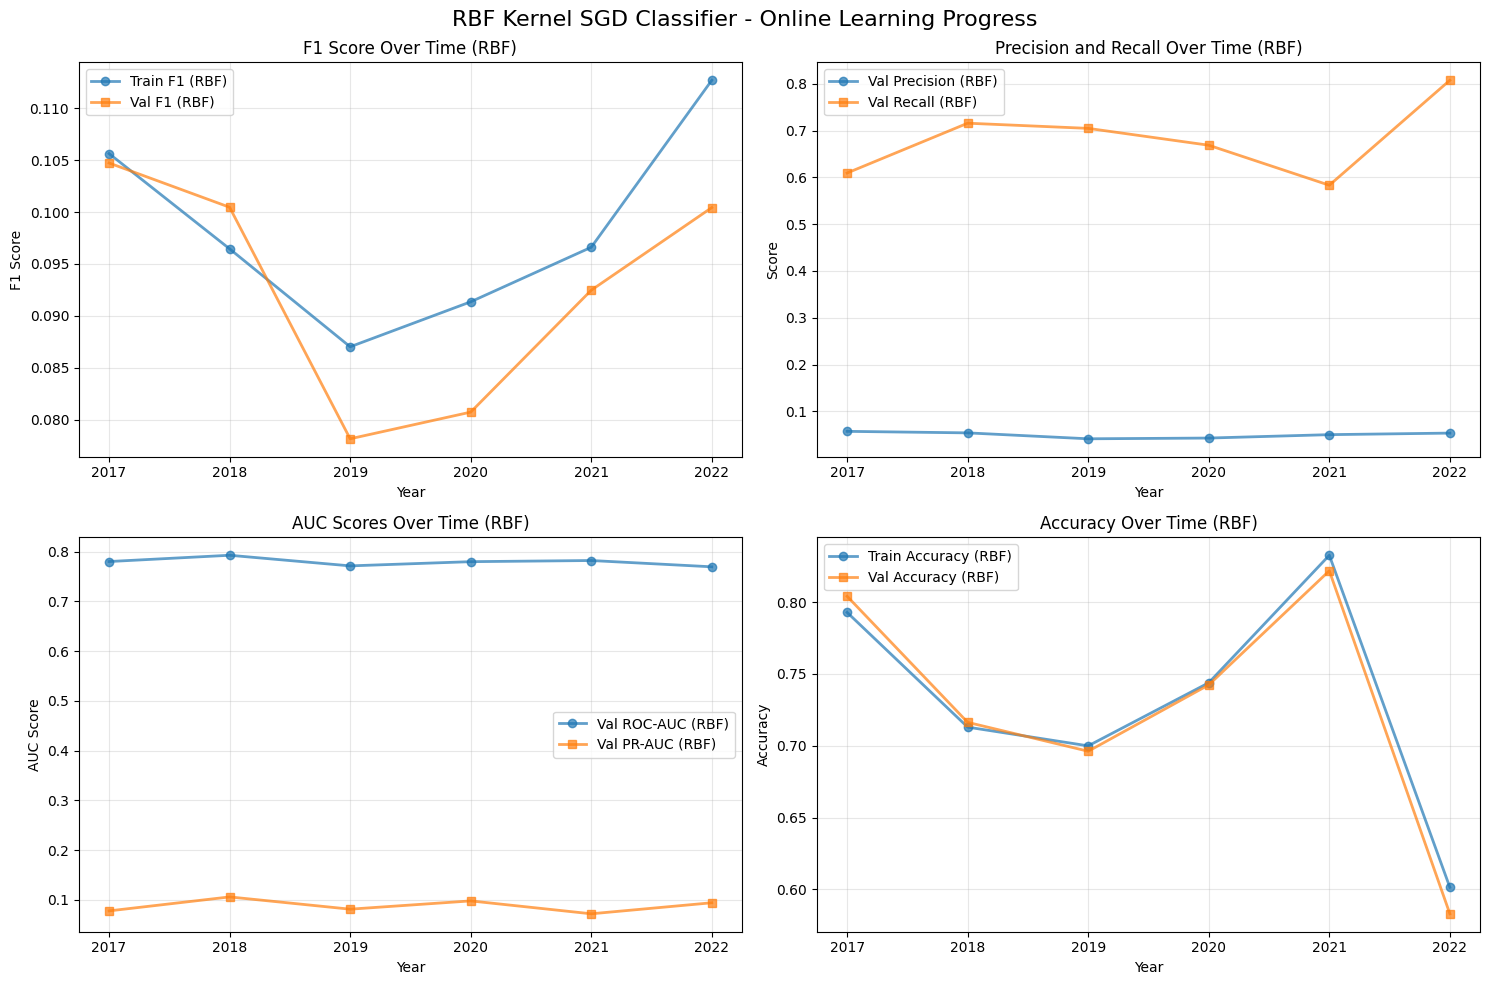


RBF VALIDATION SET SUMMARY
   year  val_accuracy  val_precision  val_recall    val_f1  val_roc_auc  \
0  2017      0.804027       0.057289    0.609294  0.104730     0.779957   
1  2018      0.716271       0.054024    0.715696  0.100464     0.792580   
2  2019      0.696147       0.041371    0.704642  0.078153     0.771238   
3  2020      0.742355       0.042955    0.668634  0.080724     0.779699   
4  2021      0.821748       0.050216    0.583144  0.092470     0.782006   
5  2022      0.583027       0.053546    0.807447  0.100433     0.769369   

   val_pr_auc  
0    0.077618  
1    0.105716  
2    0.081081  
3    0.097698  
4    0.071784  
5    0.093955  


In [11]:
# Load baseline models and history for comparison
print('=' * 80)
print('LOADING BASELINE MODELS FOR COMPARISON')
print('=' * 80)

# Try to load baseline models from disk
baseline_models_exist = all(
    (models_dir / f'model_year_{year}_prevyears_monthly_features.pkl').exists()
    for year in year_values[1:]
)

if baseline_models_exist:
    print('\n✓ Baseline models found. Loading...')
    baseline_models_by_year = {}
    for year_idx in range(1, len(ds.year)):
        year_val = year_values[year_idx]
        model_path = models_dir / f'model_year_{int(year_val)}_prevyears_monthly_features.pkl'
        with open(model_path, 'rb') as f:
            baseline_models_by_year[year_val] = pickle.load(f)
    print(f'  Loaded {len(baseline_models_by_year)} baseline models')
else:
    print('\n⚠ Baseline models not found in:', models_dir)
    print('  Cannot perform comparison without baseline models.')
    baseline_models_by_year = {}

# Convert RBF training history to DataFrame
history_df_rbf = pd.DataFrame(training_history_rbf)

# Plot RBF learning curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('RBF Kernel SGD Classifier - Online Learning Progress', fontsize=16)

# Plot 1: F1 Score
ax = axes[0, 0]
ax.plot(history_df_rbf['year'], history_df_rbf['train_f1'], label='Train F1 (RBF)', marker='o', alpha=0.7, linewidth=2)
ax.plot(history_df_rbf['year'], history_df_rbf['val_f1'], label='Val F1 (RBF)', marker='s', alpha=0.7, linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Over Time (RBF)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Precision and Recall
ax = axes[0, 1]
ax.plot(history_df_rbf['year'], history_df_rbf['val_precision'], label='Val Precision (RBF)', marker='o', alpha=0.7, linewidth=2)
ax.plot(history_df_rbf['year'], history_df_rbf['val_recall'], label='Val Recall (RBF)', marker='s', alpha=0.7, linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall Over Time (RBF)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: ROC-AUC and PR-AUC
ax = axes[1, 0]
ax.plot(history_df_rbf['year'], history_df_rbf['val_roc_auc'], label='Val ROC-AUC (RBF)', marker='o', alpha=0.7, linewidth=2)
ax.plot(history_df_rbf['year'], history_df_rbf['val_pr_auc'], label='Val PR-AUC (RBF)', marker='s', alpha=0.7, linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('AUC Score')
ax.set_title('AUC Scores Over Time (RBF)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Accuracy
ax = axes[1, 1]
ax.plot(history_df_rbf['year'], history_df_rbf['train_accuracy'], label='Train Accuracy (RBF)', marker='o', alpha=0.7, linewidth=2)
ax.plot(history_df_rbf['year'], history_df_rbf['val_accuracy'], label='Val Accuracy (RBF)', marker='s', alpha=0.7, linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Over Time (RBF)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display RBF summary statistics
print('\n' + '=' * 80)
print('RBF VALIDATION SET SUMMARY')
print('=' * 80)
print(history_df_rbf[['year', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_roc_auc', 'val_pr_auc']])


## 6. Final Evaluation on Test Set

In [12]:
# Test Set Evaluation: RBF vs Baseline Comparison
print('=' * 80)
print('TEST SET EVALUATION: RBF MM vs BASELINE LINEAR')
print('=' * 80)

decision_threshold = 0.5
print(f'\nUsing decision threshold: {decision_threshold:.4f}')

# RBF Test Evaluation
print('\n--- RBF Model Evaluation ---')
y_test_all_rbf = []
y_pred_all_rbf = []
y_proba_all_rbf = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    
    # Load year-specific scaler
    scaler_path = models_dir / f'scaler_year_{int(year_val)}_prevyears_monthly_features.pkl'
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = year_to_scaler_rbf.get(year_val)
    
    if year_scaler is None:
        continue
    
    # Prepare test data
    X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx, scaler=year_scaler)
    if len(X_test_year) == 0:
        continue
    
    # Apply RBF transformation
    X_test_year_rbf = rbf_sampler.transform(X_test_year)
    
    # Predictions
    y_proba_year = model_rbf.predict_proba(X_test_year_rbf)[:, 1]
    y_pred_year = (y_proba_year >= decision_threshold).astype(int)
    
    # Accumulate
    y_test_all_rbf.append(y_test_year)
    y_pred_all_rbf.append(y_pred_year)
    y_proba_all_rbf.append(y_proba_year)

if len(y_test_all_rbf) == 0:
    print('⚠ No RBF test samples available.')
    y_test_rbf = None
else:
    y_test_rbf = np.concatenate(y_test_all_rbf)
    y_test_pred_rbf = np.concatenate(y_pred_all_rbf)
    y_test_proba_rbf = np.concatenate(y_proba_all_rbf)
    
    # Compute metrics
    test_acc_rbf = accuracy_score(y_test_rbf, y_test_pred_rbf)
    test_prec_rbf = precision_score(y_test_rbf, y_test_pred_rbf, zero_division=0)
    test_rec_rbf = recall_score(y_test_rbf, y_test_pred_rbf, zero_division=0)
    test_f1_rbf = f1_score(y_test_rbf, y_test_pred_rbf, zero_division=0)
    test_roc_auc_rbf = roc_auc_score(y_test_rbf, y_test_proba_rbf)
    test_pr_auc_rbf = average_precision_score(y_test_rbf, y_test_proba_rbf)
    
    print(f'\nRBF Test Set Size: {y_test_rbf.shape[0]} samples')
    print(f'Accuracy:  {test_acc_rbf:.4f}')
    print(f'Precision: {test_prec_rbf:.4f}')
    print(f'Recall:    {test_rec_rbf:.4f}')
    print(f'F1 Score:  {test_f1_rbf:.4f}')
    print(f'ROC-AUC:   {test_roc_auc_rbf:.4f}')
    print(f'PR-AUC:    {test_pr_auc_rbf:.4f}')

# Baseline Test Evaluation (if available)
if baseline_models_by_year:
    print('\n--- Baseline Linear Model Evaluation ---')
    y_test_all_baseline = []
    y_pred_all_baseline = []
    y_proba_all_baseline = []
    
    for year_idx in range(1, n_years):
        year_val = year_values[year_idx]
        
        if year_val not in baseline_models_by_year:
            continue
        
        scaler_path = models_dir / f'scaler_year_{int(year_val)}_prevyears_monthly_features.pkl'
        if scaler_path.exists():
            with open(scaler_path, 'rb') as f:
                year_scaler = pickle.load(f)
        else:
            continue
        
        X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx, scaler=year_scaler)
        if len(X_test_year) == 0:
            continue
        
        # Baseline model predictions (NO RBF transformation)
        baseline_model = baseline_models_by_year[year_val]
        y_proba_year = baseline_model.predict_proba(X_test_year)[:, 1]
        y_pred_year = (y_proba_year >= decision_threshold).astype(int)
        
        y_test_all_baseline.append(y_test_year)
        y_pred_all_baseline.append(y_pred_year)
        y_proba_all_baseline.append(y_proba_year)
    
    if len(y_test_all_baseline) == 0:
        print('⚠ No baseline test samples available.')
        y_test_baseline = None
    else:
        y_test_baseline = np.concatenate(y_test_all_baseline)
        y_test_pred_baseline = np.concatenate(y_pred_all_baseline)
        y_test_proba_baseline = np.concatenate(y_proba_all_baseline)
        
        test_acc_baseline = accuracy_score(y_test_baseline, y_test_pred_baseline)
        test_prec_baseline = precision_score(y_test_baseline, y_test_pred_baseline, zero_division=0)
        test_rec_baseline = recall_score(y_test_baseline, y_test_pred_baseline, zero_division=0)
        test_f1_baseline = f1_score(y_test_baseline, y_test_pred_baseline, zero_division=0)
        test_roc_auc_baseline = roc_auc_score(y_test_baseline, y_test_proba_baseline)
        test_pr_auc_baseline = average_precision_score(y_test_baseline, y_test_proba_baseline)
        
        print(f'\nBaseline Test Set Size: {y_test_baseline.shape[0]} samples')
        print(f'Accuracy:  {test_acc_baseline:.4f}')
        print(f'Precision: {test_prec_baseline:.4f}')
        print(f'Recall:    {test_rec_baseline:.4f}')
        print(f'F1 Score:  {test_f1_baseline:.4f}')
        print(f'ROC-AUC:   {test_roc_auc_baseline:.4f}')
        print(f'PR-AUC:    {test_pr_auc_baseline:.4f}')
        
        # Comparison Summary
        print('\n' + '=' * 80)
        print('RBF vs BASELINE COMPARISON')
        print('=' * 80)
        print(f'\n{"Metric":<15} {"RBF":<12} {"Baseline":<12} {"Difference":<12}')
        print('-' * 60)
        print(f'{"Accuracy":<15} {test_acc_rbf:<12.4f} {test_acc_baseline:<12.4f} {test_acc_rbf - test_acc_baseline:+.4f}')
        print(f'{"Precision":<15} {test_prec_rbf:<12.4f} {test_prec_baseline:<12.4f} {test_prec_rbf - test_prec_baseline:+.4f}')
        print(f'{"Recall":<15} {test_rec_rbf:<12.4f} {test_rec_baseline:<12.4f} {test_rec_rbf - test_rec_baseline:+.4f}')
        print(f'{"F1 Score":<15} {test_f1_rbf:<12.4f} {test_f1_baseline:<12.4f} {test_f1_rbf - test_f1_baseline:+.4f}')
        print(f'{"ROC-AUC":<15} {test_roc_auc_rbf:<12.4f} {test_roc_auc_baseline:<12.4f} {test_roc_auc_rbf - test_roc_auc_baseline:+.4f}')
        print(f'{"PR-AUC":<15} {test_pr_auc_rbf:<12.4f} {test_pr_auc_baseline:<12.4f} {test_pr_auc_rbf - test_pr_auc_baseline:+.4f}')
else:
    print('\n⚠ Baseline models not available for comparison.')


TEST SET EVALUATION: RBF MM vs BASELINE LINEAR

Using decision threshold: 0.5000

--- RBF Model Evaluation ---


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 2
  Dropped 2303 samples with NaN values (0.2%) for year 2


...

  Dropped 291 samples with invalid labels (class 255) for year 4
  Dropped 2212 samples with NaN values (0.2%) for year 4


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2388 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

Baseline Test Set Size: 7686360 samples
Accuracy:  0.8439
Precision: 0.1021
Recall:    0.7673
F1 Score:  0.1802
ROC-AUC:   0.8818
PR-AUC:    0.3494

RBF vs BASELINE COMPARISON

Metric          RBF          Baseline     Difference  
------------------------------------------------------------
Accuracy        0.5346       0.8439       -0.3093
Precision       0.0389       0.1021       -0.0631
Recall          0.8368       0.7673       +0.0695
F1 Score        0.0744       0.1802       -0.1058
ROC-AUC         0.7592       0.8818       -0.1226
PR-AUC          0.0646       0.3494       -0.2848


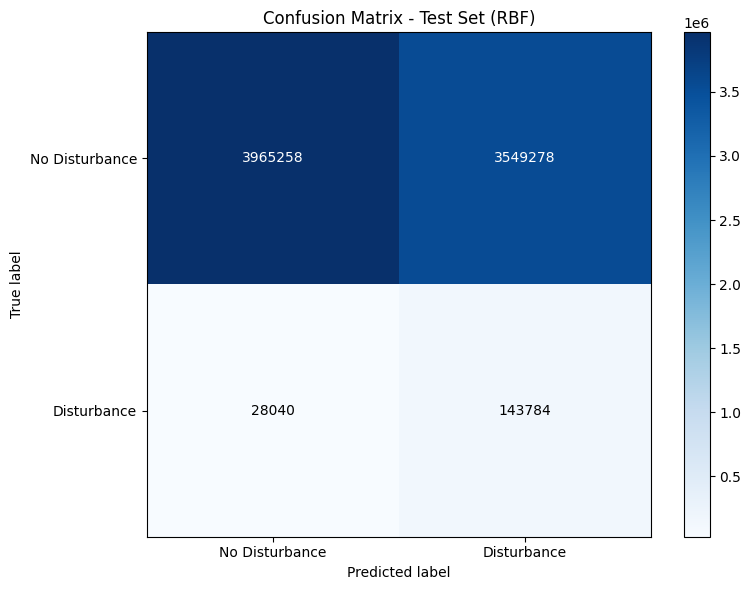

In [15]:
# Visualize confusion matrix
if 'y_test_rbf' in globals() and y_test_rbf is not None and 'y_test_pred_rbf' in globals():
    cm = confusion_matrix(y_test_rbf, y_test_pred_rbf)
    cm_title = 'Confusion Matrix - Test Set (RBF)'
elif 'y_test_baseline' in globals() and y_test_baseline is not None and 'y_test_pred_baseline' in globals():
    cm = confusion_matrix(y_test_baseline, y_test_pred_baseline)
    cm_title = 'Confusion Matrix - Test Set (Baseline)'
else:
    raise ValueError('No test predictions found. Run Cell 20 (Final Evaluation on Test Set) first.')

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['No Disturbance', 'Disturbance'],
       yticklabels=['No Disturbance', 'Disturbance'],
       title=cm_title,
       ylabel='True label',
       xlabel='Predicted label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import precision_recall_curve

print('='*80)
print('DYNAMIC THRESHOLD SELECTION (Validation PR Curve)')
print('='*80)

# Choose model path (RBF first, then linear fallback)
use_rbf_path = 'model_rbf' in globals()
if use_rbf_path:
    eval_model = model_rbf
    model_label = 'RBF'
    if 'rbf_sampler' not in globals():
        raise ValueError('rbf_sampler not found. Run Cell 13 (RBF setup) first.')
else:
    if 'model' not in globals():
        raise ValueError('No model object found. Run training cells first.')
    eval_model = model
    model_label = 'Linear'

if not hasattr(eval_model, 'classes_'):
    raise ValueError(f'{model_label} model is not fitted. Run the training cell before threshold tuning.')

print(f'Using {model_label} model for threshold tuning.')

# Collect validation probabilities across years using saved scalers
y_val_all = []
y_val_proba_all = []
year_scaler_cache = globals().get('year_to_scaler_rbf', globals().get('year_to_scaler', {}))
for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    scaler_path = models_dir / f'scaler_year_{int(year_val)}_prevyears_monthly_features.pkl'
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = year_scaler_cache.get(year_val)
    if year_scaler is None:
        continue

    X_val_year, y_val_year, _ = prepare_features_for_year(ds, val_pixel_indices, year_idx, scaler=year_scaler)
    if len(X_val_year) == 0:
        continue

    X_val_eval = rbf_sampler.transform(X_val_year) if use_rbf_path else X_val_year
    y_val_all.append(y_val_year)
    y_val_proba_all.append(eval_model.predict_proba(X_val_eval)[:, 1])

if len(y_val_all) == 0:
    raise ValueError('No validation samples available for threshold tuning.')

# Concatenate validation labels and probabilities
y_val_concat = np.concatenate(y_val_all)
y_val_proba_concat = np.concatenate(y_val_proba_all)

# Validation PR curve and AUPRC
val_pr_auc = average_precision_score(y_val_concat, y_val_proba_concat)
precision_vals, recall_vals, thresholds = precision_recall_curve(y_val_concat, y_val_proba_concat)
f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)
best_idx = f1_vals.argmax()
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f'Validation AUPRC: {val_pr_auc:.4f}')
print(f'Best threshold (max F1 on PR curve): {best_threshold:.4f}')
print(f'  Precision={precision_vals[best_idx]:.4f}, Recall={recall_vals[best_idx]:.4f}, F1={f1_vals[best_idx]:.4f}')

# Resolve test probabilities from previously computed evaluation outputs
if use_rbf_path and 'y_test_rbf' in globals() and y_test_rbf is not None and 'y_test_proba_rbf' in globals():
    y_test_ref = y_test_rbf
    y_test_proba_ref = y_test_proba_rbf
    test_label = 'RBF'
elif 'y_test' in globals() and 'y_test_proba' in globals():
    y_test_ref = y_test
    y_test_proba_ref = y_test_proba
    test_label = 'Linear'
elif 'y_test_baseline' in globals() and y_test_baseline is not None and 'y_test_proba_baseline' in globals():
    y_test_ref = y_test_baseline
    y_test_proba_ref = y_test_proba_baseline
    test_label = 'Baseline'
else:
    raise ValueError('No test probabilities found. Run Cell 20 (Final Evaluation on Test Set) first.')

# Apply dynamic threshold to selected test probabilities
y_test_pred_dyn = (y_test_proba_ref >= best_threshold).astype(int)
dyn_cm = confusion_matrix(y_test_ref, y_test_pred_dyn)
tn, fp, fn, tp = dyn_cm.ravel()
dyn_fp_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan

# Test metrics with dynamic threshold
test_acc_dyn = accuracy_score(y_test_ref, y_test_pred_dyn)
test_prec_dyn = precision_score(y_test_ref, y_test_pred_dyn, zero_division=0)
test_rec_dyn = recall_score(y_test_ref, y_test_pred_dyn, zero_division=0)
test_f1_dyn = f1_score(y_test_ref, y_test_pred_dyn, zero_division=0)
test_pr_auc_dyn = average_precision_score(y_test_ref, y_test_proba_ref)

print('\n=== TEST SET WITH DYNAMIC THRESHOLD ===')
print(f'Model/Test stream: {test_label}')
print(f'Threshold: {best_threshold:.4f}')
print(f'Accuracy:  {test_acc_dyn:.4f}')
print(f'Precision: {test_prec_dyn:.4f}')
print(f'Recall:    {test_rec_dyn:.4f}')
print(f'F1 Score:  {test_f1_dyn:.4f}')
print(f'False Positive Rate: {dyn_fp_rate:.4f}')
print('Confusion Matrix:')
print(dyn_cm)


DYNAMIC THRESHOLD SELECTION (Validation PR Curve)
Using RBF model for threshold tuning.


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 2511 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 2
  Dropped 1630 samples with NaN values (0.1%) for year 2


...

  Dropped 101 samples with invalid labels (class 255) for year 4
  Dropped 1707 samples with NaN values (0.1%) for year 4


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 5
  Dropped 1697 samples with NaN values (0.1%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 727 samples with NaN values (0.1%) for year 6
Validation AUPRC: 0.0582
Best threshold (max F1 on PR curve): 0.8398
  Precision=0.0760, Recall=0.2688, F1=0.1185

=== TEST SET WITH DYNAMIC THRESHOLD ===
Model/Test stream: RBF
Threshold: 0.8398
Accuracy:  0.9144
Precision: 0.0835
Recall:    0.2838
F1 Score:  0.1291
False Positive Rate: 0.0712
Confusion Matrix:
[[6979547  534989]
 [ 123065   48759]]


## 7. Save Model and Results

In [19]:
import json
import pickle

use_rbf = 'model_rbf' in globals() and hasattr(model_rbf, 'classes_')
active_model = model_rbf if use_rbf else model
variant_tag = 'rbf' if use_rbf else 'linear'
output_suffix = 'prevyears_monthly_features_rbf' if use_rbf else 'prevyears_monthly_features'

# Save trained model
model_path = Path('.') / f'sgd_classifier_model_{output_suffix}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(active_model, f)
print(f'✓ {variant_tag.upper()} model saved to {model_path}')

# Note on scaler location
print('✓ Per-year scalers are stored under models_prevyears_monthly_features/ as scaler_year_YYYY_prevyears_monthly_features.pkl')

# Save training history
history_obj = training_history_rbf if use_rbf and 'training_history_rbf' in globals() else globals().get('training_history')
if history_obj is None:
    raise ValueError('Training history not found. Run the training cell first.')

history_df_out = pd.DataFrame(history_obj) if isinstance(history_obj, dict) else history_obj
history_path = Path('.') / f'sgd_classifier_history_{output_suffix}.csv'
history_df_out.to_csv(history_path, index=False)
print(f'✓ Training history saved to {history_path}')

# Build test result payload from active stream
if use_rbf:
    required_vars = [
        'test_acc_rbf', 'test_prec_rbf', 'test_rec_rbf', 'test_f1_rbf',
        'test_roc_auc_rbf', 'test_pr_auc_rbf',
        'y_test_rbf', 'y_test_pred_rbf', 'y_test_proba_rbf'
    ]
    missing_vars = [name for name in required_vars if name not in globals()]
    if missing_vars:
        raise ValueError(f'Missing RBF test outputs. Run Cell 20 first. Missing: {missing_vars}')

    y_true_save = y_test_rbf
    y_pred_save = y_test_pred_rbf
    y_proba_save = y_test_proba_rbf

    test_results = {
        'variant': 'rbf',
        'accuracy': float(test_acc_rbf),
        'precision': float(test_prec_rbf),
        'recall': float(test_rec_rbf),
        'f1_score': float(test_f1_rbf),
        'roc_auc': float(test_roc_auc_rbf),
        'pr_auc': float(test_pr_auc_rbf)
    }
else:
    required_vars = [
        'test_acc', 'test_prec', 'test_rec', 'test_f1',
        'test_roc_auc', 'test_pr_auc',
        'y_test', 'y_test_pred', 'y_test_proba'
    ]
    missing_vars = [name for name in required_vars if name not in globals()]
    if missing_vars:
        raise ValueError(f'Missing test outputs. Run evaluation first. Missing: {missing_vars}')

    y_true_save = y_test
    y_pred_save = y_test_pred
    y_proba_save = y_test_proba

    test_results = {
        'variant': 'linear',
        'accuracy': float(test_acc),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'f1_score': float(test_f1),
        'roc_auc': float(test_roc_auc),
        'pr_auc': float(test_pr_auc)
    }

cm_save = confusion_matrix(y_true_save, y_pred_save)
test_results['confusion_matrix'] = cm_save.tolist()
test_results['decision_threshold'] = float(globals().get('decision_threshold', 0.5))

if 'best_threshold' in globals():
    test_results['best_threshold'] = float(best_threshold)

if 'test_acc_dyn' in globals():
    test_results['dynamic_threshold_metrics'] = {
        'accuracy': float(test_acc_dyn),
        'precision': float(test_prec_dyn),
        'recall': float(test_rec_dyn),
        'f1_score': float(test_f1_dyn),
        'pr_auc': float(test_pr_auc_dyn),
        'false_positive_rate': float(dyn_fp_rate),
        'confusion_matrix': dyn_cm.tolist() if 'dyn_cm' in globals() else None
    }

if use_rbf and 'test_acc_baseline' in globals():
    test_results['baseline_comparison'] = {
        'baseline_accuracy': float(test_acc_baseline),
        'baseline_precision': float(test_prec_baseline),
        'baseline_recall': float(test_rec_baseline),
        'baseline_f1_score': float(test_f1_baseline),
        'baseline_roc_auc': float(test_roc_auc_baseline),
        'baseline_pr_auc': float(test_pr_auc_baseline)
    }

results_path = Path('.') / f'sgd_classifier_test_results_{output_suffix}.json'
with open(results_path, 'w') as f:
    json.dump(test_results, f, indent=2)
print(f'✓ Test results saved to {results_path}')


✓ RBF model saved to sgd_classifier_model_prevyears_monthly_features_rbf.pkl
✓ Per-year scalers are stored under models_prevyears_monthly_features/ as scaler_year_YYYY_prevyears_monthly_features.pkl
✓ Training history saved to sgd_classifier_history_prevyears_monthly_features_rbf.csv
✓ Test results saved to sgd_classifier_test_results_prevyears_monthly_features_rbf.json


## 8. Feature Importance Analysis


Top 15 Most Important RBF Features:


,Feature,Coefficient,Abs_Coefficient
27,RBF_component_027,-3.737869,3.737869
99,RBF_component_099,3.622561,3.622561
48,RBF_component_048,-2.797739,2.797739
11,RBF_component_011,-2.197755,2.197755
42,RBF_component_042,1.780825,1.780825
57,RBF_component_057,1.756226,1.756226
84,RBF_component_084,1.598164,1.598164
59,RBF_component_059,1.593383,1.593383
71,RBF_component_071,1.517595,1.517595
28,RBF_component_028,-1.464239,1.464239


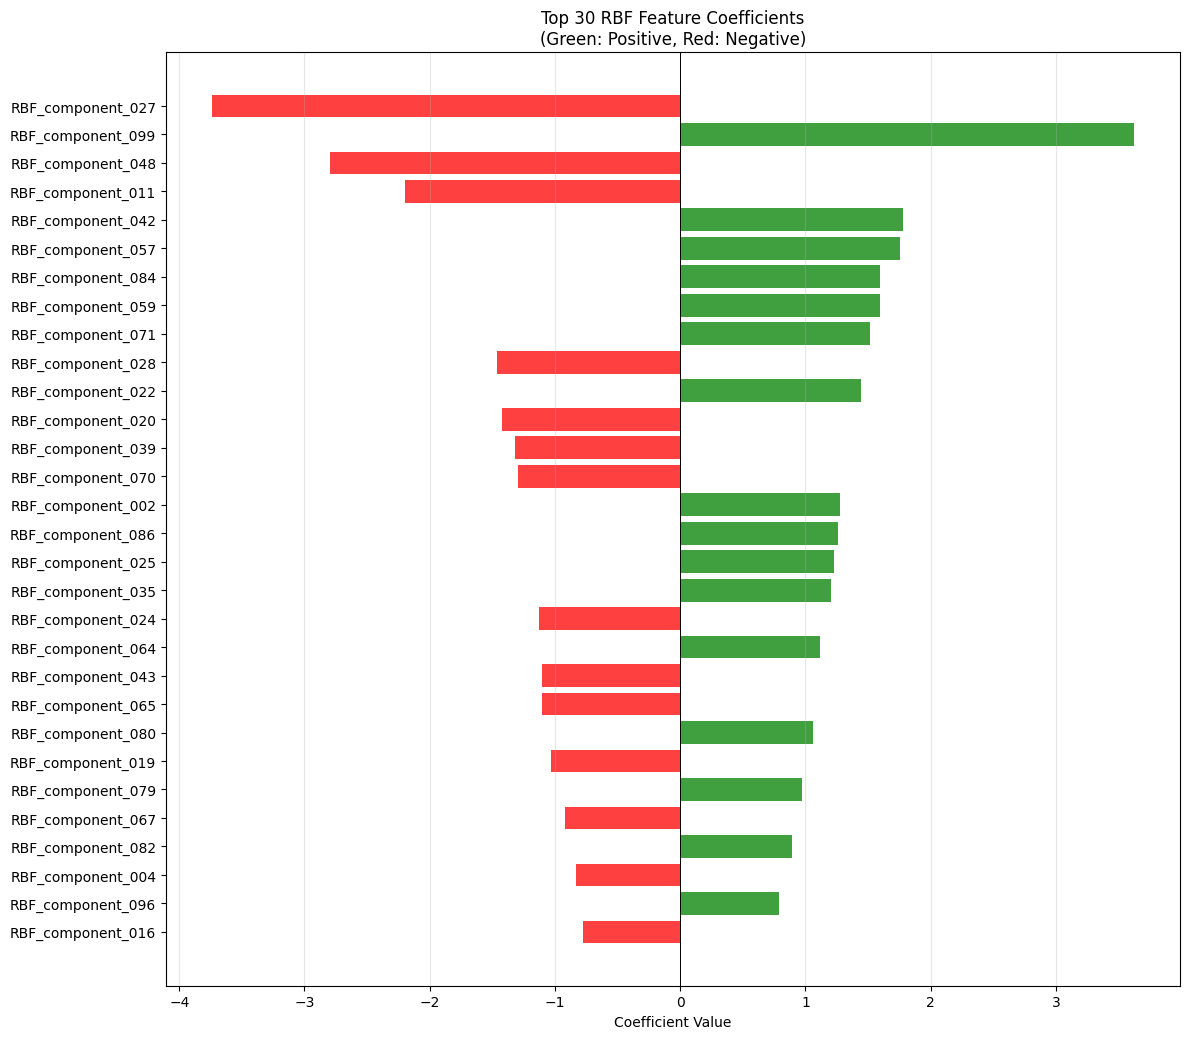

In [20]:
# Feature importance for the active model stream (RBF or linear)
if 'model_rbf' in globals() and hasattr(model_rbf, 'coef_'):
    active_model = model_rbf
    model_label = 'RBF'
elif 'model' in globals() and hasattr(model, 'coef_'):
    active_model = model
    model_label = 'Linear'
else:
    raise ValueError('No fitted model with coefficients found. Run training first.')

coefficients = active_model.coef_[0]

if model_label == 'RBF':
    # RBF coefficients correspond to transformed components, not original raw features.
    feature_names = [f'RBF_component_{i:03d}' for i in range(len(coefficients))]
else:
    feature_names = [f'Feature_{i:03d}' for i in range(len(coefficients))]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print(f'\nTop 15 Most Important {model_label} Features:')
display(importance_df.head(15))

# Plot top coefficients for readability
top_n = min(30, len(importance_df))
top_features = importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(12, max(8, top_n * 0.35)))
colors = ['red' if c < 0 else 'green' for c in top_features['Coefficient']]
ax.barh(range(top_n), top_features['Coefficient'], color=colors, alpha=0.75)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Top {top_n} {model_label} Feature Coefficients\n(Green: Positive, Red: Negative)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.7)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## 9. Per-Year Model Evaluation on Test Sets

PER-YEAR MODEL EVALUATION ON TEST SETS
Using decision threshold: 0.8398



C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1

Year 2017 (RBF, Test samples: 1278700):
  Accuracy:  0.9730
  Precision: 0.1613
  Recall:    0.1164
  F1 Score:  0.1353
  ROC-AUC:   0.8227
  PR-AUC:    0.0965


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 2
  Dropped 2303 samples with NaN values (0.2%) for year 2

Year 2018 (RBF, Test samples: 1281398):
  Accuracy:  0.9577
  Precision: 0.1503
  Recall:    0.1905
  F1 Score:  0.1680
  ROC-AUC:   0.7716
  PR-AUC:    0.0914


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2388 samples with NaN values (0.2%) for year 5

Year 2021 (RBF, Test samples: 1281313):
  Accuracy:  0.9801
  Precision: 0.2073
  Recall:    0.0639
  F1 Score:  0.0977
  ROC-AUC:   0.7924
  PR-AUC:    0.0951


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

Year 2022 (RBF, Test samples: 1282452):
  Accuracy:  0.9208
  Precision: 0.1401
  Recall:    0.2939
  F1 Score:  0.1897
  ROC-AUC:   0.7863
  PR-AUC:    0.1099

SUMMARY TABLE - PER-YEAR TEST RESULTS


,year,model_variant,n_test_samples,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,RBF,1278700,0.973009,0.161327,0.116432,0.135251,0.822684,0.096467
1,2018,RBF,1281398,0.957712,0.150297,0.190503,0.168028,0.771564,0.091447
2,2019,RBF,1281008,0.972533,0.185345,0.097379,0.127678,0.755170,0.083381
3,2020,RBF,1281489,0.970420,0.246574,0.100873,0.143174,0.785963,0.118747
4,2021,RBF,1281313,0.980056,0.207279,0.063941,0.097733,0.792437,0.095057
5,2022,RBF,1282452,0.920845,0.140067,0.293904,0.189719,0.786316,0.109887


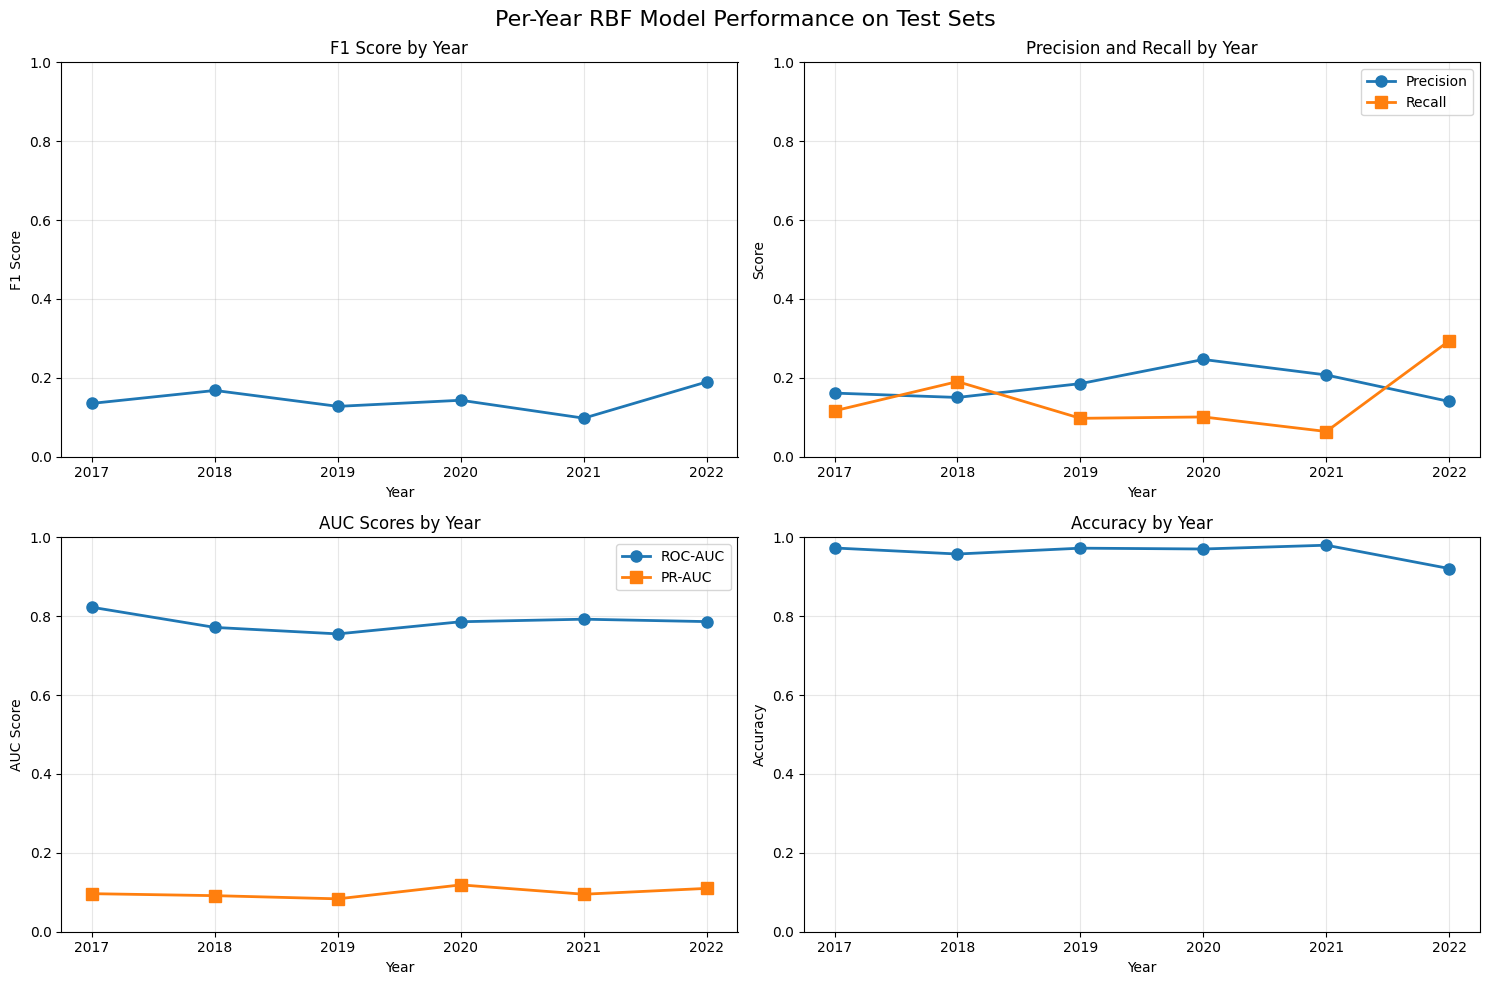

In [21]:
# Evaluate each year's saved model on that same year's test set
print('='*80)
print('PER-YEAR MODEL EVALUATION ON TEST SETS')
print('='*80)

decision_threshold = float(globals().get('best_threshold', globals().get('decision_threshold', 0.5)))
print(f'Using decision threshold: {decision_threshold:.4f}\n')

use_rbf = 'rbf_sampler' in globals()
model_variant = 'RBF' if use_rbf else 'Linear'
model_store_dir = models_rbf_dir if use_rbf else models_dir
model_file_template = 'model_year_{year}_rbf.pkl' if use_rbf else 'model_year_{year}_prevyears_monthly_features.pkl'
scaler_fallback = globals().get('year_to_scaler_rbf', globals().get('year_to_scaler', {}))

yearly_results = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    year_model_path = model_store_dir / model_file_template.format(year=int(year_val))
    scaler_path = models_dir / f'scaler_year_{int(year_val)}_prevyears_monthly_features.pkl'

    if not year_model_path.exists():
        print(f'\nYear {year_val}: model file not found at {year_model_path.name}, skipping...')
        continue

    with open(year_model_path, 'rb') as f:
        year_model = pickle.load(f)

    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = scaler_fallback.get(year_val)

    if year_scaler is None:
        print(f'\nYear {year_val}: scaler not found, skipping...')
        continue

    X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx, scaler=year_scaler)
    if len(X_test_year) == 0:
        print(f'\nYear {year_val}: no test samples after preprocessing, skipping...')
        continue

    X_eval = rbf_sampler.transform(X_test_year) if use_rbf else X_test_year
    y_proba_year = year_model.predict_proba(X_eval)[:, 1]
    y_pred_year = (y_proba_year >= decision_threshold).astype(int)

    acc = accuracy_score(y_test_year, y_pred_year)
    prec = precision_score(y_test_year, y_pred_year, zero_division=0)
    rec = recall_score(y_test_year, y_pred_year, zero_division=0)
    f1 = f1_score(y_test_year, y_pred_year, zero_division=0)

    if len(np.unique(y_test_year)) > 1:
        roc_auc = roc_auc_score(y_test_year, y_proba_year)
        pr_auc = average_precision_score(y_test_year, y_proba_year)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    yearly_results.append({
        'year': year_val,
        'model_variant': model_variant,
        'n_test_samples': len(X_test_year),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })

    print(f'\nYear {year_val} ({model_variant}, Test samples: {len(X_test_year)}):')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'  PR-AUC:    {pr_auc:.4f}')

yearly_results_df = pd.DataFrame(yearly_results)

print('\n' + '='*80)
print('SUMMARY TABLE - PER-YEAR TEST RESULTS')
print('='*80)
display(yearly_results_df)

if not yearly_results_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Per-Year {model_variant} Model Performance on Test Sets', fontsize=16)

    ax = axes[0, 0]
    ax.plot(yearly_results_df['year'], yearly_results_df['f1_score'], marker='o', linewidth=2, markersize=8)
    ax.set_xlabel('Year')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score by Year')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[0, 1]
    ax.plot(yearly_results_df['year'], yearly_results_df['precision'], label='Precision', marker='o', linewidth=2, markersize=8)
    ax.plot(yearly_results_df['year'], yearly_results_df['recall'], label='Recall', marker='s', linewidth=2, markersize=8)
    ax.set_xlabel('Year')
    ax.set_ylabel('Score')
    ax.set_title('Precision and Recall by Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 0]
    ax.plot(yearly_results_df['year'], yearly_results_df['roc_auc'], label='ROC-AUC', marker='o', linewidth=2, markersize=8)
    ax.plot(yearly_results_df['year'], yearly_results_df['pr_auc'], label='PR-AUC', marker='s', linewidth=2, markersize=8)
    ax.set_xlabel('Year')
    ax.set_ylabel('AUC Score')
    ax.set_title('AUC Scores by Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 1]
    ax.plot(yearly_results_df['year'], yearly_results_df['accuracy'], marker='o', linewidth=2, markersize=8)
    ax.set_xlabel('Year')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy by Year')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()


## 10. Positive Rate Analysis by Split and Year

In [ ]:
# Calculate positive (disturbance) rates for each split by year
print('='*80)
print('POSITIVE RATE ANALYSIS BY SPLIT AND YEAR')
print('='*80)

split_positive_rates = []
scaler_fallback = globals().get('year_to_scaler_rbf', globals().get('year_to_scaler', {}))

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]

    scaler_path = models_dir / f'scaler_year_{int(year_val)}_prevyears_monthly_features.pkl'
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = scaler_fallback.get(year_val)

    # If missing, fit from train for this year to keep processing consistent.
    if year_scaler is None:
        X_train_year, y_train_year, year_scaler = prepare_features_for_year(ds, train_pixel_indices, year_idx, scaler=None)
    else:
        X_train_year, y_train_year, _ = prepare_features_for_year(ds, train_pixel_indices, year_idx, scaler=year_scaler)

    X_val_year, y_val_year, _ = prepare_features_for_year(ds, val_pixel_indices, year_idx, scaler=year_scaler)
    X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx, scaler=year_scaler)

    if len(y_train_year) == 0 or len(y_val_year) == 0 or len(y_test_year) == 0:
        print(f'\nYear {year_val}: Skipped (missing data in one or more splits)')
        continue

    train_pos_rate = (y_train_year == 1).sum() / len(y_train_year)
    val_pos_rate = (y_val_year == 1).sum() / len(y_val_year)
    test_pos_rate = (y_test_year == 1).sum() / len(y_test_year)

    split_positive_rates.append({
        'year': year_val,
        'train_positive_rate': train_pos_rate,
        'train_total_samples': len(y_train_year),
        'train_positive_count': (y_train_year == 1).sum(),
        'val_positive_rate': val_pos_rate,
        'val_total_samples': len(y_val_year),
        'val_positive_count': (y_val_year == 1).sum(),
        'test_positive_rate': test_pos_rate,
        'test_total_samples': len(y_test_year),
        'test_positive_count': (y_test_year == 1).sum()
    })

    print(f'\nYear {year_val}:')
    print(f'  Train: {train_pos_rate:.2%} ({(y_train_year == 1).sum()}/{len(y_train_year)} samples)')
    print(f'  Val:   {val_pos_rate:.2%} ({(y_val_year == 1).sum()}/{len(y_val_year)} samples)')
    print(f'  Test:  {test_pos_rate:.2%} ({(y_test_year == 1).sum()}/{len(y_test_year)} samples)')

positive_rates_df = pd.DataFrame(split_positive_rates)

print('\n' + '='*80)
print('SUMMARY TABLE - POSITIVE RATES BY SPLIT AND YEAR')
print('='*80)
display(positive_rates_df[['year', 'train_positive_rate', 'val_positive_rate', 'test_positive_rate']])

if not positive_rates_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Positive (Disturbance) Rates by Split and Year', fontsize=14)

    ax = axes[0]
    ax.plot(positive_rates_df['year'], positive_rates_df['train_positive_rate'], label='Train', marker='o', linewidth=2, markersize=8, alpha=0.7)
    ax.plot(positive_rates_df['year'], positive_rates_df['val_positive_rate'], label='Val', marker='s', linewidth=2, markersize=8, alpha=0.7)
    ax.plot(positive_rates_df['year'], positive_rates_df['test_positive_rate'], label='Test', marker='^', linewidth=2, markersize=8, alpha=0.7)
    ax.set_xlabel('Year')
    ax.set_ylabel('Positive Rate')
    ax.set_title('Positive Rate Over Time by Split')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1]
    x_pos = np.arange(len(positive_rates_df))
    width = 0.25
    ax.bar(x_pos - width, positive_rates_df['train_total_samples'], width, label='Train', alpha=0.7)
    ax.bar(x_pos, positive_rates_df['val_total_samples'], width, label='Val', alpha=0.7)
    ax.bar(x_pos + width, positive_rates_df['test_total_samples'], width, label='Test', alpha=0.7)
    ax.set_xlabel('Year')
    ax.set_ylabel('Total Samples')
    ax.set_title('Sample Count by Split and Year')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([int(y) for y in positive_rates_df['year']])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

print('\n' + '='*80)
print('STATISTICS - POSITIVE RATES')
print('='*80)
print('\nTrain Positive Rate:')
print(positive_rates_df['train_positive_rate'].describe())
print('\nVal Positive Rate:')
print(positive_rates_df['val_positive_rate'].describe())
print('\nTest Positive Rate:')
print(positive_rates_df['test_positive_rate'].describe())


## 11.Final Model evaluation on each year's test set

In [22]:
# Evaluate the final trained model on each year's test set (summary table)
print('='*80)
print('FINAL MODEL EVALUATION ON EACH YEAR\'S TEST SET')
print('='*80)

decision_threshold = float(globals().get('best_threshold', globals().get('decision_threshold', 0.5)))
print(f'Using decision threshold: {decision_threshold:.4f}\n')

use_rbf = 'model_rbf' in globals() and hasattr(model_rbf, 'classes_')
final_model = model_rbf if use_rbf else model
variant_label = 'RBF' if use_rbf else 'Linear'
scaler_fallback = globals().get('year_to_scaler_rbf', globals().get('year_to_scaler', {}))

final_model_results = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    scaler_path = models_dir / f'scaler_year_{int(year_val)}_prevyears_monthly_features.pkl'
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = scaler_fallback.get(year_val)
    if year_scaler is None:
        print(f'Year {year_val}: Scaler not found, skipping...')
        continue

    X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx, scaler=year_scaler)
    if len(X_test_year) == 0:
        continue

    X_eval = rbf_sampler.transform(X_test_year) if use_rbf else X_test_year
    y_proba = final_model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= decision_threshold).astype(int)

    acc = accuracy_score(y_test_year, y_pred)
    prec = precision_score(y_test_year, y_pred, zero_division=0)
    rec = recall_score(y_test_year, y_pred, zero_division=0)
    f1 = f1_score(y_test_year, y_pred, zero_division=0)

    if len(np.unique(y_test_year)) > 1:
        roc_auc = roc_auc_score(y_test_year, y_proba)
        pr_auc = average_precision_score(y_test_year, y_proba)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    final_model_results.append({
        'year': year_val,
        'model_variant': variant_label,
        'n_test_samples': len(X_test_year),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })

final_model_results_df = pd.DataFrame(final_model_results)

print('\n' + '='*80)
print('SUMMARY TABLE - FINAL MODEL ON PER-YEAR TEST SETS')
print('='*80)
display(final_model_results_df)


FINAL MODEL EVALUATION ON EACH YEAR'S TEST SET
Using decision threshold: 0.8398



C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 2
  Dropped 2303 samples with NaN values (0.2%) for year 2


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2388 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

SUMMARY TABLE - FINAL MODEL ON PER-YEAR TEST SETS


,year,model_variant,n_test_samples,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,RBF,1278700,0.853667,0.058191,0.465726,0.103456,0.767290,0.050100
1,2018,RBF,1281398,0.911888,0.076029,0.262777,0.117936,0.731753,0.057711
2,2019,RBF,1281008,0.939861,0.086093,0.198994,0.120188,0.752861,0.062077
3,2020,RBF,1281489,0.924184,0.093469,0.240795,0.134666,0.762392,0.069565
4,2021,RBF,1281313,0.935751,0.079186,0.263756,0.121804,0.772917,0.055663
5,2022,RBF,1282452,0.920845,0.140067,0.293904,0.189719,0.786316,0.109887


## 12. Cumulative Test Set Evaluation

CUMULATIVE TEST SET EVALUATION
Using decision threshold: 0.8398



C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1

Year 2017 model on cumulative test set (2017-2017):
  Test samples: 1,278,700
  Accuracy:  0.9730
  Precision: 0.1613
  Recall:    0.1164
  F1 Score:  0.1353
  ROC-AUC:   0.8227
  PR-AUC:    0.0965


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 5001 samples with NaN values (0.4%) for year 1


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2388 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

Year 2022 model on cumulative test set (2017-2022):
  Test samples: 7,686,360
  Accuracy:  0.9428
  Precision: 0.0972
  Recall:    0.1883
  F1 Score:  0.1282
  ROC-AUC:   0.7219
  PR-AUC:    0.0634

SUMMARY TABLE - CUMULATIVE TEST SET RESULTS


,year,model_variant,n_test_samples,years_included,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,RBF,1278700,2017-2017,0.973009,0.161327,0.116432,0.135251,0.822684,0.096467
1,2018,RBF,2560098,2017-2018,0.964122,0.110481,0.109142,0.109807,0.656804,0.052122
2,2019,RBF,3841106,2017-2019,0.972299,0.095851,0.042464,0.058855,0.660297,0.043821
3,2020,RBF,5122595,2017-2020,0.974223,0.177012,0.055684,0.084718,0.695296,0.066444
4,2021,RBF,6403908,2017-2021,0.976906,0.175099,0.033846,0.056727,0.702118,0.064526
5,2022,RBF,7686360,2017-2022,0.942757,0.097215,0.188344,0.128239,0.721901,0.063390


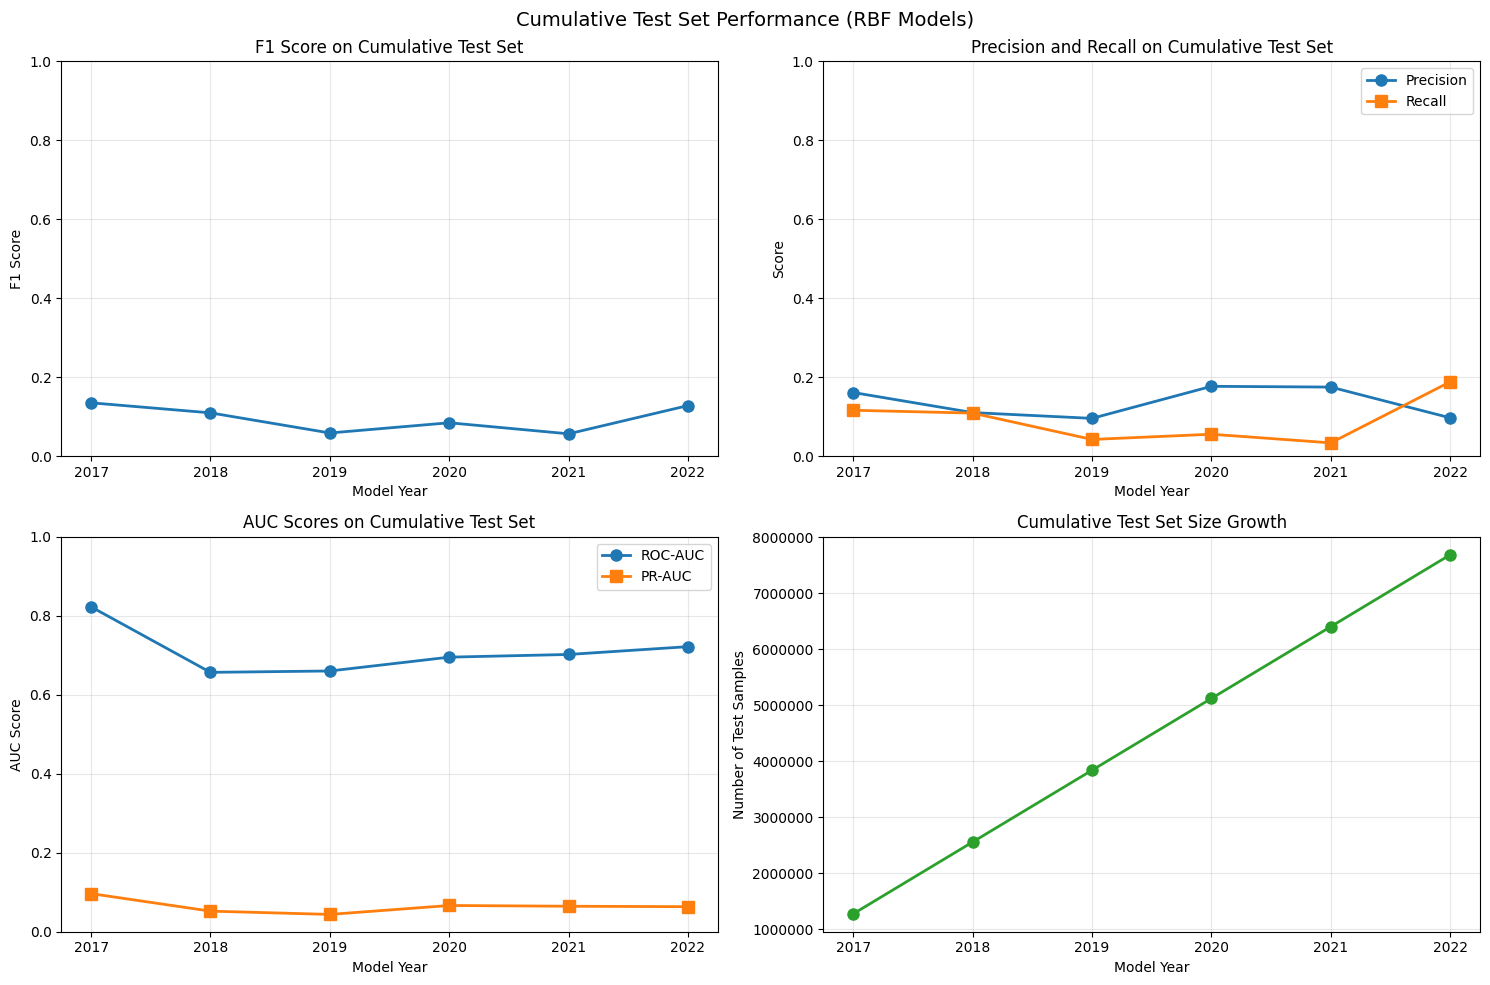

In [24]:
# Evaluate each year's model on cumulative test sets (that year + all previous years)
print('='*80)
print('CUMULATIVE TEST SET EVALUATION')
print('='*80)

decision_threshold = float(globals().get('best_threshold', globals().get('decision_threshold', 0.5)))
print(f'Using decision threshold: {decision_threshold:.4f}\n')

use_rbf = 'rbf_sampler' in globals()
model_variant = 'RBF' if use_rbf else 'Linear'
model_store_dir = models_rbf_dir if use_rbf else models_dir
model_file_template = 'model_year_{year}_rbf.pkl' if use_rbf else 'model_year_{year}_prevyears_monthly_features.pkl'
scaler_fallback = globals().get('year_to_scaler_rbf', globals().get('year_to_scaler', {}))

cumulative_results = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    year_model_path = model_store_dir / model_file_template.format(year=int(year_val))
    scaler_path = models_dir / f'scaler_year_{int(year_val)}_prevyears_monthly_features.pkl'

    if not year_model_path.exists():
        print(f'\nYear {year_val}: model file not found, skipping...')
        continue
    with open(year_model_path, 'rb') as f:
        year_model = pickle.load(f)

    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = scaler_fallback.get(year_val)
    if year_scaler is None:
        print(f'\nYear {year_val}: scaler not found, skipping...')
        continue

    # Stream predictions year-by-year to avoid large X matrix allocations.
    y_cumulative = []
    y_proba_cumulative_parts = []
    total_tn, total_fp, total_fn, total_tp = 0, 0, 0, 0
    n_total_samples = 0

    for past_year_idx in range(1, year_idx + 1):
        X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, past_year_idx, scaler=year_scaler)
        if len(X_test_year) == 0:
            continue

        X_eval_year = rbf_sampler.transform(X_test_year) if use_rbf else X_test_year
        y_proba_year = year_model.predict_proba(X_eval_year)[:, 1]
        y_pred_year = (y_proba_year >= decision_threshold).astype(np.uint8)

        cm_year = confusion_matrix(y_test_year, y_pred_year, labels=[0, 1])
        tn, fp, fn, tp = cm_year.ravel()
        total_tn += int(tn)
        total_fp += int(fp)
        total_fn += int(fn)
        total_tp += int(tp)
        n_total_samples += len(y_test_year)

        y_cumulative.append(y_test_year.astype(np.uint8))
        y_proba_cumulative_parts.append(y_proba_year.astype(np.float32))

    if len(y_cumulative) == 0:
        print(f'\nYear {year_val}: no cumulative test data available, skipping...')
        continue

    y_test_cumulative = np.concatenate(y_cumulative)
    y_proba_cumulative = np.concatenate(y_proba_cumulative_parts)

    acc = (total_tp + total_tn) / max(1, n_total_samples)
    prec = total_tp / max(1, (total_tp + total_fp))
    rec = total_tp / max(1, (total_tp + total_fn))
    f1 = (2 * prec * rec) / max(1e-12, (prec + rec))

    if len(np.unique(y_test_cumulative)) > 1:
        roc_auc = roc_auc_score(y_test_cumulative, y_proba_cumulative)
        pr_auc = average_precision_score(y_test_cumulative, y_proba_cumulative)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    cumulative_results.append({
        'year': year_val,
        'model_variant': model_variant,
        'n_test_samples': n_total_samples,
        'years_included': f'2017-{int(year_val)}',
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })

    print(f'\nYear {year_val} model on cumulative test set (2017-{int(year_val)}):')
    print(f'  Test samples: {n_total_samples:,}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'  PR-AUC:    {pr_auc:.4f}')

cumulative_results_df = pd.DataFrame(cumulative_results)

print('\n' + '='*80)
print('SUMMARY TABLE - CUMULATIVE TEST SET RESULTS')
print('='*80)
display(cumulative_results_df)

if not cumulative_results_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Cumulative Test Set Performance ({model_variant} Models)', fontsize=14)

    ax = axes[0, 0]
    ax.plot(cumulative_results_df['year'], cumulative_results_df['f1_score'], marker='o', linewidth=2, markersize=8, color='tab:blue')
    ax.set_xlabel('Model Year')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score on Cumulative Test Set')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[0, 1]
    ax.plot(cumulative_results_df['year'], cumulative_results_df['precision'], label='Precision', marker='o', linewidth=2, markersize=8)
    ax.plot(cumulative_results_df['year'], cumulative_results_df['recall'], label='Recall', marker='s', linewidth=2, markersize=8)
    ax.set_xlabel('Model Year')
    ax.set_ylabel('Score')
    ax.set_title('Precision and Recall on Cumulative Test Set')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 0]
    ax.plot(cumulative_results_df['year'], cumulative_results_df['roc_auc'], label='ROC-AUC', marker='o', linewidth=2, markersize=8)
    ax.plot(cumulative_results_df['year'], cumulative_results_df['pr_auc'], label='PR-AUC', marker='s', linewidth=2, markersize=8)
    ax.set_xlabel('Model Year')
    ax.set_ylabel('AUC Score')
    ax.set_title('AUC Scores on Cumulative Test Set')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 1]
    ax.plot(cumulative_results_df['year'], cumulative_results_df['n_test_samples'], marker='o', linewidth=2, markersize=8, color='tab:green')
    ax.set_xlabel('Model Year')
    ax.set_ylabel('Number of Test Samples')
    ax.set_title('Cumulative Test Set Size Growth')
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')

    plt.tight_layout()
    plt.show()


## 13. Next-Year Model Evaluation
Evaluate each year model on the next year's test set (year t -> year t+1)

In [25]:
# Evaluate each year's model on the next year's test set (year t -> year t+1)
print('='*80)
print('NEXT-YEAR MODEL EVALUATION (Year t model on Year t+1 test set)')
print('='*80)

decision_threshold = float(globals().get('best_threshold', globals().get('decision_threshold', 0.5)))
print(f'Using decision threshold: {decision_threshold:.4f}\n')

use_rbf = 'rbf_sampler' in globals()
model_variant = 'RBF' if use_rbf else 'Linear'
model_store_dir = models_rbf_dir if use_rbf else models_dir
model_file_template = 'model_year_{year}_rbf.pkl' if use_rbf else 'model_year_{year}_prevyears_monthly_features.pkl'
scaler_fallback = globals().get('year_to_scaler_rbf', globals().get('year_to_scaler', {}))

next_year_results = []

for year_idx in range(1, n_years - 1):
    year_val = year_values[year_idx]
    next_year_val = year_values[year_idx + 1]
    year_model_path = model_store_dir / model_file_template.format(year=int(year_val))
    scaler_path = models_dir / f'scaler_year_{int(year_val)}_prevyears_monthly_features.pkl'

    if not year_model_path.exists():
        print(f'\nYear {year_val}: model file not found, skipping...')
        continue
    with open(year_model_path, 'rb') as f:
        year_model = pickle.load(f)

    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = scaler_fallback.get(year_val)
    if year_scaler is None:
        print(f'\nYear {year_val}: scaler not found, skipping...')
        continue

    X_test_next, y_test_next, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx + 1, scaler=year_scaler)
    if len(X_test_next) == 0:
        print(f'\nYear {year_val} -> {next_year_val}: no test samples available, skipping...')
        continue

    X_eval_next = rbf_sampler.transform(X_test_next) if use_rbf else X_test_next
    y_proba_next = year_model.predict_proba(X_eval_next)[:, 1]
    y_pred_next = (y_proba_next >= decision_threshold).astype(int)

    acc = accuracy_score(y_test_next, y_pred_next)
    prec = precision_score(y_test_next, y_pred_next, zero_division=0)
    rec = recall_score(y_test_next, y_pred_next, zero_division=0)
    f1 = f1_score(y_test_next, y_pred_next, zero_division=0)

    if len(np.unique(y_test_next)) > 1:
        roc_auc = roc_auc_score(y_test_next, y_proba_next)
        pr_auc = average_precision_score(y_test_next, y_proba_next)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    next_year_results.append({
        'year': year_val,
        'model_variant': model_variant,
        'next_year': next_year_val,
        'n_test_samples': len(X_test_next),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })

    print(f'\nModel year {year_val} -> Test year {next_year_val} (samples: {len(X_test_next)}):')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'  PR-AUC:    {pr_auc:.4f}')

next_year_results_df = pd.DataFrame(next_year_results)

print('\n' + '='*80)
print('SUMMARY TABLE - NEXT-YEAR TEST RESULTS')
print('='*80)
display(next_year_results_df)


NEXT-YEAR MODEL EVALUATION (Year t model on Year t+1 test set)
Using decision threshold: 0.8398



C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 2
  Dropped 2303 samples with NaN values (0.2%) for year 2

Model year 2017 -> Test year 2018 (samples: 1281398):
  Accuracy:  0.9720
  Precision: 0.0847
  Recall:    0.0255
  F1 Score:  0.0392
  ROC-AUC:   0.7665
  PR-AUC:    0.0675


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 3
  Dropped 2693 samples with NaN values (0.2%) for year 3

Model year 2018 -> Test year 2019 (samples: 1281008):
  Accuracy:  0.9446
  Precision: 0.0298
  Recall:    0.0534
  F1 Score:  0.0383
  ROC-AUC:   0.5886
  PR-AUC:    0.0271


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2388 samples with NaN values (0.2%) for year 5

Model year 2020 -> Test year 2021 (samples: 1281313):
  Accuracy:  0.9775
  Precision: 0.2162
  Recall:    0.1260
  F1 Score:  0.1592
  ROC-AUC:   0.7738
  PR-AUC:    0.0989


C:\Users\bartu\AppData\Local\Temp\ipykernel_43532\1999320485.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1249 samples with NaN values (0.1%) for year 6

Model year 2021 -> Test year 2022 (samples: 1282452):
  Accuracy:  0.9640
  Precision: 0.1900
  Recall:    0.0438
  F1 Score:  0.0712
  ROC-AUC:   0.7340
  PR-AUC:    0.0955

SUMMARY TABLE - NEXT-YEAR TEST RESULTS


,year,model_variant,next_year,n_test_samples,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,RBF,2018,1281398,0.971985,0.084742,0.025484,0.039184,0.766538,0.067490
1,2018,RBF,2019,1281008,0.944626,0.029842,0.053398,0.038287,0.588625,0.027095
2,2019,RBF,2020,1281489,0.967340,0.190749,0.102720,0.133532,0.778329,0.100276
3,2020,RBF,2021,1281313,0.977521,0.216223,0.125988,0.159208,0.773824,0.098906
4,2021,RBF,2022,1282452,0.963961,0.189986,0.043823,0.071219,0.733955,0.095549


## 14. Side-by-Side Comparison of All Evaluation Approaches

In [26]:
# Compare all four evaluation approaches with separate tables
print('='*80)
print('EVALUATION RESULTS: FOUR SEPARATE APPROACHES')
print('='*80)

required_tables = {
    'final_model_results_df': 'Cell 32 (Final Model Evaluation)',
    'yearly_results_df': 'Cell 28 (Per-Year Model Evaluation)',
    'cumulative_results_df': 'Cell 34 (Cumulative Evaluation)',
    'next_year_results_df': 'Cell 36 (Next-Year Evaluation)'
}
missing_tables = [name for name in required_tables if name not in globals()]
if missing_tables:
    raise ValueError(
        'Missing required result tables:\n' +
        '\n'.join([f'- {name}: run {required_tables[name]} first.' for name in missing_tables])
    )

variant_label = 'RBF' if 'rbf_sampler' in globals() else 'Linear'

print('\n' + '='*80)
print(f'TABLE 1: Final {variant_label} model (trained on all years) evaluated on each year')
print('='*80)
table1 = final_model_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table1)

print('\n' + '='*80)
print(f'TABLE 2: Year-specific {variant_label} model evaluated on that year only')
print('='*80)
table2 = yearly_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table2)

print('\n' + '='*80)
print(f'TABLE 3: Year-specific {variant_label} model evaluated on cumulative test set')
print('='*80)
table3 = cumulative_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table3)

print('\n' + '='*80)
print(f'TABLE 4: Year-specific {variant_label} model evaluated on next year\'s test set (year t -> year t+1)')
print('='*80)
table4 = next_year_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table4)

print(f"\nNote: All tables use decision threshold = {float(globals().get('best_threshold', globals().get('decision_threshold', 0.5))):.4f}.")


EVALUATION RESULTS: FOUR SEPARATE APPROACHES

TABLE 1: Final RBF model (trained on all years) evaluated on each year


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.853667,0.058191,0.465726,0.103456,0.767290,0.050100,1278700
1,2018,0.911888,0.076029,0.262777,0.117936,0.731753,0.057711,1281398
2,2019,0.939861,0.086093,0.198994,0.120188,0.752861,0.062077,1281008
3,2020,0.924184,0.093469,0.240795,0.134666,0.762392,0.069565,1281489
4,2021,0.935751,0.079186,0.263756,0.121804,0.772917,0.055663,1281313
5,2022,0.920845,0.140067,0.293904,0.189719,0.786316,0.109887,1282452



TABLE 2: Year-specific RBF model evaluated on that year only


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.973009,0.161327,0.116432,0.135251,0.822684,0.096467,1278700
1,2018,0.957712,0.150297,0.190503,0.168028,0.771564,0.091447,1281398
2,2019,0.972533,0.185345,0.097379,0.127678,0.755170,0.083381,1281008
3,2020,0.970420,0.246574,0.100873,0.143174,0.785963,0.118747,1281489
4,2021,0.980056,0.207279,0.063941,0.097733,0.792437,0.095057,1281313
5,2022,0.920845,0.140067,0.293904,0.189719,0.786316,0.109887,1282452



TABLE 3: Year-specific RBF model evaluated on cumulative test set


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.973009,0.161327,0.116432,0.135251,0.822684,0.096467,1278700
1,2018,0.964122,0.110481,0.109142,0.109807,0.656804,0.052122,2560098
2,2019,0.972299,0.095851,0.042464,0.058855,0.660297,0.043821,3841106
3,2020,0.974223,0.177012,0.055684,0.084718,0.695296,0.066444,5122595
4,2021,0.976906,0.175099,0.033846,0.056727,0.702118,0.064526,6403908
5,2022,0.942757,0.097215,0.188344,0.128239,0.721901,0.063390,7686360



TABLE 4: Year-specific RBF model evaluated on next year's test set (year t -> year t+1)


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.971985,0.084742,0.025484,0.039184,0.766538,0.067490,1281398
1,2018,0.944626,0.029842,0.053398,0.038287,0.588625,0.027095,1281008
2,2019,0.967340,0.190749,0.102720,0.133532,0.778329,0.100276,1281489
3,2020,0.977521,0.216223,0.125988,0.159208,0.773824,0.098906,1281313
4,2021,0.963961,0.189986,0.043823,0.071219,0.733955,0.095549,1282452



Note: All tables use decision threshold = 0.8398.


## 15. Standalone Prior-Years Evaluation by Model
Evaluate each model year on all prior years including its own year, computed locally in this section only.

In [ ]:
# Standalone evaluation: each model year on all prior years (including current year)
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    )

required_globals = {
    'ds': 'Run Section 1 (Load Prepared Data and Split) first.',
    'test_pixel_indices': 'Run Section 1 (Load Prepared Data and Split) first.',
    'prepare_features_for_year': 'Run Section 2 (Feature Engineering) first.',
}
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    missing_help = '\n'.join([f"- {name}: {required_globals[name]}" for name in missing_globals])
    raise RuntimeError(
        'Missing required notebook objects for standalone prior-years evaluation:\n'
        f'{missing_help}'
    )

use_rbf = 'rbf_sampler' in globals()
model_variant = 'RBF' if use_rbf else 'Linear'
models_dir_local = Path(globals().get('models_rbf_dir', Path('.') / 'models_prevyears_monthly_features_rbf')) if use_rbf else Path(globals().get('models_dir', Path('.') / 'models_prevyears_monthly_features'))
scaler_dir_local = Path(globals().get('models_dir', Path('.') / 'models_prevyears_monthly_features'))
model_file_template = 'model_year_{year}_rbf.pkl' if use_rbf else 'model_year_{year}_prevyears_monthly_features.pkl'

if not models_dir_local.exists():
    raise FileNotFoundError(
        f'Model directory not found: {models_dir_local.resolve()}\n'
        'Train and save yearly models/scalers before running this section.'
    )

n_years_local = len(ds.year)
year_values_local = ds.year.values
result_columns = [
    'year',
    'model_variant',
    'accuracy',
    'precision',
    'recall',
    'f1_score',
    'roc_auc',
    'pr_auc',
    'n_test_samples',
    'scaler_year_used',
    'threshold_used',
    'threshold_source',
    'threshold_reason',
    'n_val_threshold_samples',
]

print(f'Using models directory: {models_dir_local.resolve()}')
print(f'Model variant: {model_variant}')

global_fallback_threshold = float(globals().get('best_threshold', globals().get('decision_threshold', 0.5)))
print(f'Global fallback threshold: {global_fallback_threshold:.4f}')

has_val_indices = 'val_pixel_indices' in globals()
if not has_val_indices:
    print('Warning: val_pixel_indices not found. Eval-year threshold tuning is disabled; fallback threshold will be used.')

standalone_prior_year_tables = {}
model_year_thresholds = {}
model_year_threshold_meta = {}
model_eval_year_thresholds = {}
model_eval_year_threshold_meta = {}

scaler_cache = {}
scaler_fallback = globals().get('year_to_scaler_rbf', globals().get('year_to_scaler', {}))

def transform_for_variant(X):
    return rbf_sampler.transform(X) if use_rbf else X

def load_scaler_for_year(year_val):
    year_key = int(year_val)
    if year_key in scaler_cache:
        return scaler_cache[year_key]

    scaler_path_year = scaler_dir_local / f'scaler_year_{year_key}_prevyears_monthly_features.pkl'
    scaler_obj = None

    if scaler_path_year.exists():
        with open(scaler_path_year, 'rb') as f:
            scaler_obj = pickle.load(f)
    else:
        scaler_obj = scaler_fallback.get(year_val, scaler_fallback.get(year_key))

    if scaler_obj is not None:
        scaler_cache[year_key] = scaler_obj
    return scaler_obj

def compute_eval_year_threshold(year_model, eval_year_idx, eval_year_scaler):
    threshold_local = global_fallback_threshold
    threshold_source = 'fallback_global'
    threshold_reason = 'best_threshold/default'
    n_val_threshold_samples = 0

    if not has_val_indices:
        return threshold_local, threshold_source, threshold_reason, n_val_threshold_samples

    X_val_year, y_val_year, _ = prepare_features_for_year(
        ds,
        val_pixel_indices,
        eval_year_idx,
        scaler=eval_year_scaler,
    )

    if len(X_val_year) == 0:
        threshold_reason = 'no validation samples after preprocessing'
        return threshold_local, threshold_source, threshold_reason, n_val_threshold_samples

    n_val_threshold_samples = int(len(y_val_year))
    X_val_eval = transform_for_variant(X_val_year)
    y_val_proba = year_model.predict_proba(X_val_eval)[:, 1]

    if len(np.unique(y_val_year)) > 1:
        precision_vals, recall_vals, thresholds = precision_recall_curve(y_val_year, y_val_proba)
        f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)
        best_idx = int(np.argmax(f1_vals))

        if best_idx < len(thresholds):
            threshold_local = float(thresholds[best_idx])
            threshold_source = 'computed_pr_f1_eval_year'
            threshold_reason = f'max F1 on eval-year {int(year_values_local[eval_year_idx])} validation PR curve'
        else:
            threshold_reason = 'PR argmax at terminal point without explicit threshold'
    else:
        threshold_reason = 'validation labels contain one class only'

    return threshold_local, threshold_source, threshold_reason, n_val_threshold_samples

print('=' * 80)
print('STANDALONE PRIOR-YEARS EVALUATION BY MODEL YEAR')
print('=' * 80)

for model_year_idx in range(1, n_years_local):
    model_year_val = year_values_local[model_year_idx]
    model_year_key = int(model_year_val)
    model_path = models_dir_local / model_file_template.format(year=model_year_key)

    if not model_path.exists():
        print(f'\nModel year {model_year_key}: model file not found, skipping.')
        continue

    with open(model_path, 'rb') as f:
        year_model = pickle.load(f)

    model_eval_year_thresholds[model_year_key] = {}
    model_eval_year_threshold_meta[model_year_key] = {}
    model_year_rows = []

    print(f'\nModel year {model_year_key}: evaluating years <= {model_year_key} using each eval year\'s scaler.')

    for eval_year_idx in range(1, model_year_idx + 1):
        eval_year_val = year_values_local[eval_year_idx]
        eval_year_key = int(eval_year_val)

        eval_year_scaler = load_scaler_for_year(eval_year_val)
        if eval_year_scaler is None:
            print(f'  Model {model_year_key} -> Eval {eval_year_key}: eval-year scaler not found, skipped.')
            continue

        threshold_local, threshold_source, threshold_reason, n_val_threshold_samples = compute_eval_year_threshold(
            year_model,
            eval_year_idx,
            eval_year_scaler,
        )

        model_eval_year_thresholds[model_year_key][eval_year_key] = threshold_local
        model_eval_year_threshold_meta[model_year_key][eval_year_key] = {
            'source': threshold_source,
            'reason': threshold_reason,
            'n_val_samples': int(n_val_threshold_samples),
        }

        X_eval, y_eval, _ = prepare_features_for_year(
            ds,
            test_pixel_indices,
            eval_year_idx,
            scaler=eval_year_scaler,
        )

        if len(X_eval) == 0:
            print(f'  Model {model_year_key} -> Eval {eval_year_key}: no samples after preprocessing, skipped.')
            continue

        X_eval_transformed = transform_for_variant(X_eval)
        y_proba = year_model.predict_proba(X_eval_transformed)[:, 1]
        y_pred = (y_proba >= threshold_local).astype(np.uint8)

        acc = accuracy_score(y_eval, y_pred)
        prec = precision_score(y_eval, y_pred, zero_division=0)
        rec = recall_score(y_eval, y_pred, zero_division=0)
        f1 = f1_score(y_eval, y_pred, zero_division=0)

        if len(np.unique(y_eval)) > 1:
            roc_auc = roc_auc_score(y_eval, y_proba)
            pr_auc = average_precision_score(y_eval, y_proba)
        else:
            roc_auc = np.nan
            pr_auc = np.nan

        model_year_rows.append({
            'year': eval_year_val,
            'model_variant': model_variant,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
            'n_test_samples': len(X_eval),
            'scaler_year_used': eval_year_key,
            'threshold_used': threshold_local,
            'threshold_source': threshold_source,
            'threshold_reason': threshold_reason,
            'n_val_threshold_samples': int(n_val_threshold_samples),
        })

        print(f'  Model {model_year_key} -> Eval {eval_year_key}: threshold={threshold_local:.4f} ({threshold_source}), F1={f1:.4f}')

    if not model_year_rows:
        print(f'\nModel year {model_year_key}: no evaluable prior-year data, table not created.')
        continue

    own_year_threshold = model_eval_year_thresholds[model_year_key].get(model_year_key)
    own_year_meta = model_eval_year_threshold_meta[model_year_key].get(model_year_key)

    if own_year_threshold is not None and own_year_meta is not None:
        model_year_thresholds[model_year_key] = own_year_threshold
        model_year_threshold_meta[model_year_key] = own_year_meta.copy()
    else:
        model_year_thresholds[model_year_key] = global_fallback_threshold
        model_year_threshold_meta[model_year_key] = {
            'source': 'fallback_global',
            'reason': 'own-year threshold unavailable',
            'n_val_samples': 0,
        }

    model_year_df = pd.DataFrame(model_year_rows)
    ordered_columns = [col for col in result_columns if col in model_year_df.columns]
    model_year_df = model_year_df[ordered_columns].copy()
    standalone_prior_year_tables[model_year_key] = model_year_df

    print('\n' + '=' * 80)
    print(f'MODEL YEAR {model_year_key} -> EVALUATED ON YEARS <= {model_year_key}')
    print('=' * 80)
    display(model_year_df)

if not standalone_prior_year_tables:
    print('\nNo standalone prior-years tables were produced.')
else:
    print(f'\nGenerated {len(standalone_prior_year_tables)} standalone prior-years tables.')
    print('Per-model/eval-year thresholds are available in model_eval_year_thresholds.')
    print('Backward-compatible per-model thresholds are available in model_year_thresholds.')


In [ ]:
# Diagnostic: why some later model years can get F1=0 on year 2017
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
    accuracy_score,
    roc_auc_score,
    )

required_objects = {
    'ds': 'Run Cell 4 (load dataset/splits) first.',
    'test_pixel_indices': 'Run Cell 4 (load dataset/splits) first.',
    'prepare_features_for_year': 'Run Cell 6 (feature engineering) first.',
}
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    msg = '\n'.join([f"- {name}: {required_objects[name]}" for name in missing_objects])
    raise RuntimeError(f'Missing required objects:\n{msg}')

use_rbf = 'rbf_sampler' in globals()
model_variant = 'RBF' if use_rbf else 'Linear'
models_dir_diag = Path(globals().get('models_rbf_dir', Path('.') / 'models_prevyears_monthly_features_rbf')) if use_rbf else Path(globals().get('models_dir', Path('.') / 'models_prevyears_monthly_features'))
scaler_dir_diag = Path(globals().get('models_dir', Path('.') / 'models_prevyears_monthly_features'))
model_file_template = 'model_year_{year}_rbf.pkl' if use_rbf else 'model_year_{year}_prevyears_monthly_features.pkl'

if not models_dir_diag.exists():
    raise FileNotFoundError(f'Model directory not found: {models_dir_diag.resolve()}')

year_values_diag = ds.year.values
if len(year_values_diag) < 2:
    raise RuntimeError('Dataset does not contain evaluable years (year index 1 is missing).')

eval_year_idx = 1
eval_year_val = int(year_values_diag[eval_year_idx])
global_default_threshold = float(globals().get('best_threshold', globals().get('decision_threshold', 0.5)))
saved_model_thresholds = globals().get('model_year_thresholds', {})

print('=' * 100)
print(f'DIAGNOSTIC ({model_variant}): MODEL-YEAR BEHAVIOR ON EVAL YEAR {eval_year_val}')
print('=' * 100)
print(f'Model directory: {models_dir_diag.resolve()}')
print(f'Global fallback threshold: {global_default_threshold:.4f}')

def transform_for_variant(X):
    return rbf_sampler.transform(X) if use_rbf else X

# Optional probe: compare with eval-year scaler to detect scaling mismatch effects.
eval_year_scaler = None
eval_year_scaler_path = scaler_dir_diag / f'scaler_year_{eval_year_val}_prevyears_monthly_features.pkl'
if eval_year_scaler_path.exists():
    with open(eval_year_scaler_path, 'rb') as f:
        eval_year_scaler = pickle.load(f)

diagnostic_rows = []

# Focus on model years after 2017 because this is where F1=0 was observed.
for model_year_idx in range(2, len(year_values_diag)):
    model_year_val = int(year_values_diag[model_year_idx])
    model_path = models_dir_diag / model_file_template.format(year=model_year_val)
    scaler_path = scaler_dir_diag / f'scaler_year_{model_year_val}_prevyears_monthly_features.pkl'

    if not model_path.exists() or not scaler_path.exists():
        print(f'Model year {model_year_val}: missing model/scaler file, skipped.')
        continue

    with open(model_path, 'rb') as f:
        year_model = pickle.load(f)
    with open(scaler_path, 'rb') as f:
        model_year_scaler = pickle.load(f)

    if model_year_val in saved_model_thresholds:
        threshold_local = float(saved_model_thresholds[model_year_val])
        threshold_source = 'model_year_thresholds'
    else:
        threshold_local = global_default_threshold
        threshold_source = 'global_fallback'

    # Evaluate with model-year scaler (same setup as standalone prior-years section).
    X_eval, y_eval, _ = prepare_features_for_year(
        ds,
        test_pixel_indices,
        eval_year_idx,
        scaler=model_year_scaler,
    )

    if len(X_eval) == 0:
        print(f'Model year {model_year_val}: no evaluable samples for year {eval_year_val}.')
        continue

    X_eval_transformed = transform_for_variant(X_eval)
    y_proba = year_model.predict_proba(X_eval_transformed)[:, 1]
    y_pred = (y_proba >= threshold_local).astype(np.uint8)

    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_eval, y_pred, zero_division=0)
    recall = recall_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)
    acc = accuracy_score(y_eval, y_pred)

    if len(np.unique(y_eval)) > 1:
        roc_auc = roc_auc_score(y_eval, y_proba)
        pr_auc = average_precision_score(y_eval, y_proba)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    p_vals, r_vals, pr_thresholds = precision_recall_curve(y_eval, y_proba)
    f1_curve = 2.0 * (p_vals * r_vals) / (p_vals + r_vals + 1e-12)
    best_idx = int(np.argmax(f1_curve))
    oracle_best_f1 = float(f1_curve[best_idx])
    oracle_best_threshold = float(pr_thresholds[best_idx]) if best_idx < len(pr_thresholds) else np.nan

    # Optional: evaluate same model/year with eval-year scaler to quantify scaling effect.
    f1_with_eval_year_scaler = np.nan
    pred_pos_rate_with_eval_year_scaler = np.nan
    if eval_year_scaler is not None:
        X_eval_ref, y_eval_ref, _ = prepare_features_for_year(
            ds,
            test_pixel_indices,
            eval_year_idx,
            scaler=eval_year_scaler,
        )
        if len(X_eval_ref) > 0:
            X_eval_ref_transformed = transform_for_variant(X_eval_ref)
            y_proba_ref = year_model.predict_proba(X_eval_ref_transformed)[:, 1]
            y_pred_ref = (y_proba_ref >= threshold_local).astype(np.uint8)
            f1_with_eval_year_scaler = f1_score(y_eval_ref, y_pred_ref, zero_division=0)
            pred_pos_rate_with_eval_year_scaler = float((y_pred_ref == 1).mean())

    q50, q90, q95, q99 = np.quantile(y_proba, [0.50, 0.90, 0.95, 0.99])
    label_pos_rate = float((y_eval == 1).mean())
    pred_pos_rate = float((y_pred == 1).mean())

    diagnostic_rows.append({
        'model_variant': model_variant,
        'model_year': model_year_val,
        'threshold': threshold_local,
        'threshold_source': threshold_source,
        'n_eval_samples_2017': int(len(y_eval)),
        'label_pos_rate_2017': label_pos_rate,
        'pred_pos_rate_2017': pred_pos_rate,
        'accuracy_2017': float(acc),
        'precision_2017': float(precision),
        'recall_2017': float(recall),
        'f1_2017': float(f1),
        'roc_auc_2017': float(roc_auc) if not np.isnan(roc_auc) else np.nan,
        'pr_auc_2017': float(pr_auc) if not np.isnan(pr_auc) else np.nan,
        'tp_2017': int(tp),
        'fp_2017': int(fp),
        'fn_2017': int(fn),
        'tn_2017': int(tn),
        'proba_q50': float(q50),
        'proba_q90': float(q90),
        'proba_q95': float(q95),
        'proba_q99': float(q99),
        'oracle_best_f1_2017': oracle_best_f1,
        'oracle_best_threshold_2017': oracle_best_threshold,
        'f1_2017_with_eval_year_scaler': float(f1_with_eval_year_scaler) if not np.isnan(f1_with_eval_year_scaler) else np.nan,
        'pred_pos_rate_2017_with_eval_year_scaler': float(pred_pos_rate_with_eval_year_scaler) if not np.isnan(pred_pos_rate_with_eval_year_scaler) else np.nan,
    })

if not diagnostic_rows:
    print('No diagnostic rows were produced.')
else:
    diagnostic_df = pd.DataFrame(diagnostic_rows).sort_values('model_year').reset_index(drop=True)
    display(diagnostic_df)

    print('\n' + '-' * 100)
    print('ROWS WITH F1_2017 == 0')
    print('-' * 100)
    zero_f1_df = diagnostic_df[diagnostic_df['f1_2017'] == 0].copy()
    if zero_f1_df.empty:
        print('No zero-F1 rows on 2017 were found for model years after 2017 in this run.')
    else:
        display(
            zero_f1_df[[
                'model_year',
                'threshold',
                'label_pos_rate_2017',
                'pred_pos_rate_2017',
                'tp_2017',
                'fn_2017',
                'proba_q95',
                'proba_q99',
                'oracle_best_f1_2017',
                'oracle_best_threshold_2017',
                'f1_2017_with_eval_year_scaler',
            ]]
        )

    print('\n' + '-' * 100)
    print('QUICK INTERPRETATION GUIDE')
    print('-' * 100)
    print('- If pred_pos_rate_2017 is near 0 while label_pos_rate_2017 is not, thresholding is suppressing positives.')
    print('- If threshold > proba_q99, nearly all predictions will be negative.')
    print('- If oracle_best_f1_2017 >> f1_2017, fixed threshold is likely the main issue.')
    print('- If f1_2017_with_eval_year_scaler is much higher, scaler mismatch contributes to the drop.')


In [7]:
# Final diagnostic: paired scaler comparison to prove/disprove scaler mismatch
import io
import pickle
import warnings
from contextlib import redirect_stdout
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)

print('=' * 100)
print('SCALER MISMATCH VERDICT DIAGNOSTIC')
print('=' * 100)
print('Paired comparison: same model, same evaluation year, same threshold; only the scaler changes.')
print('Positive deltas mean the eval-year scaler outperforms the model-year scaler.\n')

required_objects = {
    'ds': 'Run Section 1 first.',
    'test_pixel_indices': 'Run Section 1 first.',
    'prepare_features_for_year': 'Run Section 2 first.',
    'rbf_sampler': 'Run the RBF setup and training cells first.',
}
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    missing_text = '\n'.join([f"- {name}: {required_objects[name]}" for name in missing_objects])
    raise RuntimeError(f'Missing required notebook objects:\n{missing_text}')

models_dir_verdict = Path(globals().get('models_rbf_dir', Path('.') / 'models_prevyears_monthly_features_rbf'))
scaler_dir_verdict = Path(globals().get('models_dir', Path('.') / 'models_prevyears_monthly_features'))
if not models_dir_verdict.exists():
    raise FileNotFoundError(f'RBF model directory not found: {models_dir_verdict.resolve()}')
if not scaler_dir_verdict.exists():
    raise FileNotFoundError(f'Scaler directory not found: {scaler_dir_verdict.resolve()}')

year_values_verdict = ds.year.values
n_years_verdict = len(year_values_verdict)
fallback_threshold = float(globals().get('best_threshold', globals().get('decision_threshold', 0.5)))
existing_thresholds_raw = globals().get('model_year_thresholds', {})
existing_thresholds = {int(key): float(value) for key, value in existing_thresholds_raw.items()}
scaler_fallback = globals().get('year_to_scaler_rbf', globals().get('year_to_scaler', {}))

print(f'RBF model directory: {models_dir_verdict.resolve()}')
print(f'Scaler directory: {scaler_dir_verdict.resolve()}')
print(f'Fallback threshold: {fallback_threshold:.4f}')

model_cache = {}
scaler_cache = {}

def transform_features(X):
    return rbf_sampler.transform(X)

def prepare_year_silently(pixel_indices, year_idx, scaler_obj):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='Mean of empty slice', category=RuntimeWarning)
        with redirect_stdout(io.StringIO()):
            return prepare_features_for_year(ds, pixel_indices, year_idx, scaler=scaler_obj)

def best_f1_from_scores(y_true, y_proba):
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_proba)
    f1_vals = 2.0 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)
    f1_vals = np.nan_to_num(f1_vals, nan=0.0, posinf=0.0, neginf=0.0)
    best_idx = int(np.argmax(f1_vals))
    best_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else np.nan
    return float(f1_vals[best_idx]), best_threshold

def load_model_for_year(year_val):
    year_key = int(year_val)
    if year_key in model_cache:
        return model_cache[year_key]
    model_path = models_dir_verdict / f'model_year_{year_key}_rbf.pkl'
    if not model_path.exists():
        raise FileNotFoundError(f'Missing RBF model file: {model_path.resolve()}')
    with open(model_path, 'rb') as f:
        model_obj = pickle.load(f)
    model_cache[year_key] = model_obj
    return model_obj

def load_scaler_for_year(year_val):
    year_key = int(year_val)
    if year_key in scaler_cache:
        return scaler_cache[year_key]
    scaler_path = scaler_dir_verdict / f'scaler_year_{year_key}_prevyears_monthly_features.pkl'
    scaler_obj = None
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            scaler_obj = pickle.load(f)
    else:
        scaler_obj = scaler_fallback.get(year_val, scaler_fallback.get(year_key))
    if scaler_obj is None:
        raise FileNotFoundError(f'Missing scaler for year {year_key}.')
    scaler_cache[year_key] = scaler_obj
    return scaler_obj

def compute_model_year_threshold(year_model, model_year_idx, model_year_scaler):
    model_year_val = int(year_values_verdict[model_year_idx])
    if model_year_val in existing_thresholds:
        return float(existing_thresholds[model_year_val]), 'existing_model_year_thresholds', np.nan

    if 'val_pixel_indices' not in globals():
        return fallback_threshold, 'fallback_global_no_val_split', 0

    X_val_year, y_val_year, _ = prepare_year_silently(val_pixel_indices, model_year_idx, model_year_scaler)
    if len(X_val_year) == 0:
        return fallback_threshold, 'fallback_no_validation_samples', 0

    n_val_samples = int(len(y_val_year))
    if len(np.unique(y_val_year)) < 2:
        return fallback_threshold, 'fallback_single_class_validation', n_val_samples

    y_val_proba = year_model.predict_proba(transform_features(X_val_year))[:, 1]
    _, best_threshold_local = best_f1_from_scores(y_val_year, y_val_proba)
    if np.isnan(best_threshold_local):
        return fallback_threshold, 'fallback_terminal_pr_point', n_val_samples

    return float(best_threshold_local), 'computed_own_year_validation', n_val_samples

def evaluate_with_scaler(year_model, eval_year_idx, scaler_obj, threshold):
    X_eval, y_eval, _ = prepare_year_silently(test_pixel_indices, eval_year_idx, scaler_obj)
    if len(X_eval) == 0:
        return None

    y_proba = year_model.predict_proba(transform_features(X_eval))[:, 1]
    y_pred = (y_proba >= threshold).astype(np.uint8)
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()

    if len(np.unique(y_eval)) > 1:
        roc_auc = roc_auc_score(y_eval, y_proba)
        pr_auc = average_precision_score(y_eval, y_proba)
        oracle_best_f1, oracle_best_threshold = best_f1_from_scores(y_eval, y_proba)
    else:
        roc_auc = np.nan
        pr_auc = np.nan
        oracle_best_f1 = np.nan
        oracle_best_threshold = np.nan

    return {
        'y_true': y_eval,
        'n_eval_samples': int(len(y_eval)),
        'label_pos_rate': float((y_eval == 1).mean()),
        'pred_pos_rate': float((y_pred == 1).mean()),
        'accuracy': float(accuracy_score(y_eval, y_pred)),
        'precision': float(precision_score(y_eval, y_pred, zero_division=0)),
        'recall': float(recall_score(y_eval, y_pred, zero_division=0)),
        'f1': float(f1_score(y_eval, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc) if not np.isnan(roc_auc) else np.nan,
        'pr_auc': float(pr_auc) if not np.isnan(pr_auc) else np.nan,
        'oracle_best_f1': float(oracle_best_f1) if not np.isnan(oracle_best_f1) else np.nan,
        'oracle_best_threshold': float(oracle_best_threshold) if not np.isnan(oracle_best_threshold) else np.nan,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }

pair_rows = []
threshold_audit_rows = []

for model_year_idx in range(1, n_years_verdict):
    model_year_val = int(year_values_verdict[model_year_idx])
    try:
        year_model = load_model_for_year(model_year_val)
        model_year_scaler = load_scaler_for_year(model_year_val)
    except FileNotFoundError as exc:
        print(f'Skipping model year {model_year_val}: {exc}')
        continue

    threshold_local, threshold_source, n_val_threshold_samples = compute_model_year_threshold(
        year_model,
        model_year_idx,
        model_year_scaler,
    )

    threshold_audit_rows.append({
        'model_year': model_year_val,
        'threshold_used': float(threshold_local),
        'threshold_source': threshold_source,
        'n_val_threshold_samples': int(n_val_threshold_samples) if not np.isnan(n_val_threshold_samples) else np.nan,
    })

    for eval_year_idx in range(1, model_year_idx + 1):
        eval_year_val = int(year_values_verdict[eval_year_idx])
        try:
            eval_year_scaler = load_scaler_for_year(eval_year_val)
        except FileNotFoundError as exc:
            print(f'Skipping pair model {model_year_val} -> eval {eval_year_val}: {exc}')
            continue

        model_scaler_metrics = evaluate_with_scaler(
            year_model,
            eval_year_idx,
            model_year_scaler,
            threshold_local,
        )
        eval_scaler_metrics = evaluate_with_scaler(
            year_model,
            eval_year_idx,
            eval_year_scaler,
            threshold_local,
        )

        if model_scaler_metrics is None or eval_scaler_metrics is None:
            continue

        if not np.array_equal(model_scaler_metrics['y_true'], eval_scaler_metrics['y_true']):
            raise RuntimeError(
                f'Label mismatch for model year {model_year_val} and eval year {eval_year_val}; '
                'the paired scaler comparison is not valid.'
            )

        f1_delta = eval_scaler_metrics['f1'] - model_scaler_metrics['f1']
        oracle_f1_delta = eval_scaler_metrics['oracle_best_f1'] - model_scaler_metrics['oracle_best_f1']
        pr_auc_delta = eval_scaler_metrics['pr_auc'] - model_scaler_metrics['pr_auc']
        roc_auc_delta = eval_scaler_metrics['roc_auc'] - model_scaler_metrics['roc_auc']
        pred_pos_rate_delta = eval_scaler_metrics['pred_pos_rate'] - model_scaler_metrics['pred_pos_rate']

        if np.isnan(oracle_f1_delta) or np.isnan(pr_auc_delta):
            bottleneck_hint = 'insufficient_class_variation'
        elif abs(f1_delta) <= 0.01 and abs(oracle_f1_delta) <= 0.01 and abs(pr_auc_delta) <= 0.005:
            bottleneck_hint = 'no_material_scaler_effect'
        elif f1_delta >= 0.03 and abs(oracle_f1_delta) <= 0.015 and abs(pr_auc_delta) <= 0.01:
            bottleneck_hint = 'mostly_threshold_or_calibration'
        elif oracle_f1_delta >= 0.02 or pr_auc_delta >= 0.01 or abs(roc_auc_delta) >= 0.01:
            bottleneck_hint = 'scaler_changes_ranking'
        else:
            bottleneck_hint = 'mixed_or_small'

        pair_rows.append({
            'model_year': model_year_val,
            'eval_year': eval_year_val,
            'is_own_year': bool(model_year_val == eval_year_val),
            'threshold_used': float(threshold_local),
            'threshold_source': threshold_source,
            'n_val_threshold_samples': int(n_val_threshold_samples) if not np.isnan(n_val_threshold_samples) else np.nan,
            'n_eval_samples': model_scaler_metrics['n_eval_samples'],
            'label_pos_rate': model_scaler_metrics['label_pos_rate'],
            'f1_model_scaler': model_scaler_metrics['f1'],
            'f1_eval_scaler': eval_scaler_metrics['f1'],
            'f1_delta_eval_minus_model_scaler': f1_delta,
            'precision_model_scaler': model_scaler_metrics['precision'],
            'precision_eval_scaler': eval_scaler_metrics['precision'],
            'recall_model_scaler': model_scaler_metrics['recall'],
            'recall_eval_scaler': eval_scaler_metrics['recall'],
            'pred_pos_rate_model_scaler': model_scaler_metrics['pred_pos_rate'],
            'pred_pos_rate_eval_scaler': eval_scaler_metrics['pred_pos_rate'],
            'pred_pos_rate_delta_eval_minus_model_scaler': pred_pos_rate_delta,
            'roc_auc_model_scaler': model_scaler_metrics['roc_auc'],
            'roc_auc_eval_scaler': eval_scaler_metrics['roc_auc'],
            'roc_auc_delta_eval_minus_model_scaler': roc_auc_delta,
            'pr_auc_model_scaler': model_scaler_metrics['pr_auc'],
            'pr_auc_eval_scaler': eval_scaler_metrics['pr_auc'],
            'pr_auc_delta_eval_minus_model_scaler': pr_auc_delta,
            'oracle_f1_model_scaler': model_scaler_metrics['oracle_best_f1'],
            'oracle_f1_eval_scaler': eval_scaler_metrics['oracle_best_f1'],
            'oracle_f1_delta_eval_minus_model_scaler': oracle_f1_delta,
            'oracle_threshold_model_scaler': model_scaler_metrics['oracle_best_threshold'],
            'oracle_threshold_eval_scaler': eval_scaler_metrics['oracle_best_threshold'],
            'tn_model_scaler': model_scaler_metrics['tn'],
            'fp_model_scaler': model_scaler_metrics['fp'],
            'fn_model_scaler': model_scaler_metrics['fn'],
            'tp_model_scaler': model_scaler_metrics['tp'],
            'tn_eval_scaler': eval_scaler_metrics['tn'],
            'fp_eval_scaler': eval_scaler_metrics['fp'],
            'fn_eval_scaler': eval_scaler_metrics['fn'],
            'tp_eval_scaler': eval_scaler_metrics['tp'],
            'bottleneck_hint': bottleneck_hint,
        })

if not pair_rows:
    raise RuntimeError('No paired scaler-comparison rows were produced. Check saved models/scalers and executed setup cells.')

scaler_mismatch_pairwise_df = pd.DataFrame(pair_rows).sort_values(
    ['f1_delta_eval_minus_model_scaler', 'oracle_f1_delta_eval_minus_model_scaler'],
    ascending=False,
).reset_index(drop=True)
scaler_mismatch_threshold_audit_df = pd.DataFrame(threshold_audit_rows).drop_duplicates().sort_values('model_year').reset_index(drop=True)

summary_rows = []
for group_label, group_df in [
    ('own_year_control', scaler_mismatch_pairwise_df[scaler_mismatch_pairwise_df['is_own_year']]),
    ('prior_year_pairs', scaler_mismatch_pairwise_df[~scaler_mismatch_pairwise_df['is_own_year']]),
    ('all_pairs', scaler_mismatch_pairwise_df),
]:
    if group_df.empty:
        continue

    summary_rows.append({
        'group': group_label,
        'n_pairs': int(len(group_df)),
        'mean_f1_delta': float(group_df['f1_delta_eval_minus_model_scaler'].mean()),
        'median_f1_delta': float(group_df['f1_delta_eval_minus_model_scaler'].median()),
        'mean_oracle_f1_delta': float(group_df['oracle_f1_delta_eval_minus_model_scaler'].mean(skipna=True)),
        'median_oracle_f1_delta': float(group_df['oracle_f1_delta_eval_minus_model_scaler'].median(skipna=True)),
        'mean_pr_auc_delta': float(group_df['pr_auc_delta_eval_minus_model_scaler'].mean(skipna=True)),
        'median_pr_auc_delta': float(group_df['pr_auc_delta_eval_minus_model_scaler'].median(skipna=True)),
        'mean_roc_auc_delta': float(group_df['roc_auc_delta_eval_minus_model_scaler'].mean(skipna=True)),
        'pct_pairs_f1_improved_gt_0_01': float((group_df['f1_delta_eval_minus_model_scaler'] > 0.01).mean()),
        'pct_pairs_with_ranking_shift_hint': float((group_df['bottleneck_hint'] == 'scaler_changes_ranking').mean()),
        'pct_pairs_with_threshold_hint': float((group_df['bottleneck_hint'] == 'mostly_threshold_or_calibration').mean()),
    })

scaler_mismatch_summary_df = pd.DataFrame(summary_rows)

display_columns = [
    'model_year',
    'eval_year',
    'is_own_year',
    'threshold_used',
    'threshold_source',
    'n_eval_samples',
    'label_pos_rate',
    'f1_model_scaler',
    'f1_eval_scaler',
    'f1_delta_eval_minus_model_scaler',
    'oracle_f1_model_scaler',
    'oracle_f1_eval_scaler',
    'oracle_f1_delta_eval_minus_model_scaler',
    'pr_auc_model_scaler',
    'pr_auc_eval_scaler',
    'pr_auc_delta_eval_minus_model_scaler',
    'pred_pos_rate_model_scaler',
    'pred_pos_rate_eval_scaler',
    'bottleneck_hint',
]

print('\nTHRESHOLD AUDIT BY MODEL YEAR')
display(scaler_mismatch_threshold_audit_df)

print('\nPAIRWISE SCALER COMPARISON')
display(scaler_mismatch_pairwise_df[display_columns])

print('\nSUMMARY')
display(scaler_mismatch_summary_df)

own_year_df = scaler_mismatch_pairwise_df[scaler_mismatch_pairwise_df['is_own_year']]
prior_year_df = scaler_mismatch_pairwise_df[~scaler_mismatch_pairwise_df['is_own_year']]

own_year_max_abs_f1_delta = float(own_year_df['f1_delta_eval_minus_model_scaler'].abs().max()) if not own_year_df.empty else np.nan
prior_improvement_rate = float((prior_year_df['f1_delta_eval_minus_model_scaler'] > 0.01).mean()) if not prior_year_df.empty else np.nan
prior_median_f1_delta = float(prior_year_df['f1_delta_eval_minus_model_scaler'].median()) if not prior_year_df.empty else np.nan
prior_median_oracle_f1_delta = float(prior_year_df['oracle_f1_delta_eval_minus_model_scaler'].median(skipna=True)) if not prior_year_df.empty else np.nan
prior_median_pr_auc_delta = float(prior_year_df['pr_auc_delta_eval_minus_model_scaler'].median(skipna=True)) if not prior_year_df.empty else np.nan

if prior_year_df.empty:
    scaler_mismatch_verdict = 'INSUFFICIENT EVIDENCE: no prior-year pairs were available for comparison.'
elif not np.isnan(own_year_max_abs_f1_delta) and own_year_max_abs_f1_delta > 1e-10:
    scaler_mismatch_verdict = (
        'CONTROL CHECK FAILED: own-year rows changed under scaler swap, so inspect the comparison setup before drawing conclusions.'
    )
elif prior_improvement_rate >= 0.70 and (
    (not np.isnan(prior_median_oracle_f1_delta) and prior_median_oracle_f1_delta >= 0.02) or
    (not np.isnan(prior_median_pr_auc_delta) and prior_median_pr_auc_delta >= 0.01)
):
    scaler_mismatch_verdict = 'SUPPORTED: scaler mismatch is a major contributor to the prior-year performance drop.'
elif prior_improvement_rate >= 0.60 and not np.isnan(prior_median_f1_delta) and prior_median_f1_delta >= 0.02:
    scaler_mismatch_verdict = 'PARTIALLY SUPPORTED: scaler mismatch contributes, but threshold/calibration is also part of the problem.'
else:
    scaler_mismatch_verdict = 'NOT SUPPORTED: swapping to eval-year scalers does not materially improve the paired prior-year results.'

print('\n' + '=' * 100)
print('VERDICT')
print('=' * 100)
print(f'Own-year control max |F1 delta|: {own_year_max_abs_f1_delta:.6f}' if not np.isnan(own_year_max_abs_f1_delta) else 'Own-year control max |F1 delta|: n/a')
print(f'Prior-year share with F1 improvement > 0.01: {prior_improvement_rate:.2%}' if not np.isnan(prior_improvement_rate) else 'Prior-year share with F1 improvement > 0.01: n/a')
print(f'Prior-year median F1 delta: {prior_median_f1_delta:+.4f}' if not np.isnan(prior_median_f1_delta) else 'Prior-year median F1 delta: n/a')
print(f'Prior-year median oracle F1 delta: {prior_median_oracle_f1_delta:+.4f}' if not np.isnan(prior_median_oracle_f1_delta) else 'Prior-year median oracle F1 delta: n/a')
print(f'Prior-year median PR-AUC delta: {prior_median_pr_auc_delta:+.4f}' if not np.isnan(prior_median_pr_auc_delta) else 'Prior-year median PR-AUC delta: n/a')
print(scaler_mismatch_verdict)
print('\nRule of thumb:')
print('- Large F1 delta with small oracle/PR-AUC delta points to threshold/calibration.')
print('- Large oracle F1 or PR-AUC delta points to scaler mismatch changing ranking.')
print('- Near-zero deltas across prior-year pairs argue against scaler mismatch as the main cause.')

SCALER MISMATCH VERDICT DIAGNOSTIC
Paired comparison: same model, same evaluation year, same threshold; only the scaler changes.
Positive deltas mean the eval-year scaler outperforms the model-year scaler.

RBF model directory: C:\Users\bartu\Desktop\Fonda-scikit\models_prevyears_monthly_features_rbf
Scaler directory: C:\Users\bartu\Desktop\Fonda-scikit\models_prevyears_monthly_features
Fallback threshold: 0.5000

THRESHOLD AUDIT BY MODEL YEAR


,model_year,threshold_used,threshold_source,n_val_threshold_samples
0,2017,0.750468,computed_own_year_validation,1270825
1,2018,0.801521,computed_own_year_validation,1271706
2,2019,0.805310,computed_own_year_validation,1271570
3,2020,0.801609,computed_own_year_validation,1271629
4,2021,0.728766,computed_own_year_validation,1271639
5,2022,0.822155,computed_own_year_validation,1272609



PAIRWISE SCALER COMPARISON


,model_year,eval_year,is_own_year,threshold_used,threshold_source,n_eval_samples,label_pos_rate,f1_model_scaler,f1_eval_scaler,f1_delta_eval_minus_model_scaler,oracle_f1_model_scaler,oracle_f1_eval_scaler,oracle_f1_delta_eval_minus_model_scaler,pr_auc_model_scaler,pr_auc_eval_scaler,pr_auc_delta_eval_minus_model_scaler,pred_pos_rate_model_scaler,pred_pos_rate_eval_scaler,bottleneck_hint
0,2021,2017,False,0.728766,computed_own_year_validation,1278700,0.018129,0.011183,0.122029,0.110846,0.036307,0.142408,0.106101,0.017067,0.071277,0.054211,0.011803,0.109917,scaler_changes_ranking
1,2020,2017,False,0.801609,computed_own_year_validation,1278700,0.018129,0.010412,0.115128,0.104716,0.060892,0.117903,0.057011,0.028474,0.061028,0.032554,0.002001,0.094415,scaler_changes_ranking
2,2018,2017,False,0.801521,computed_own_year_validation,1278700,0.018129,0.017329,0.119640,0.102311,0.035633,0.124742,0.089109,0.017621,0.059477,0.041856,0.023933,0.103571,scaler_changes_ranking
3,2019,2017,False,0.805310,computed_own_year_validation,1278700,0.018129,0.021680,0.121575,0.099895,0.048039,0.125697,0.077658,0.022828,0.060167,0.037338,0.015707,0.090505,scaler_changes_ranking
4,2020,2018,False,0.801609,computed_own_year_validation,1281398,0.022416,0.054322,0.151849,0.097527,0.092540,0.153188,0.060648,0.042789,0.090529,0.047740,0.009678,0.037282,scaler_changes_ranking
5,2019,2018,False,0.805310,computed_own_year_validation,1281398,0.022416,0.043310,0.133682,0.090373,0.083794,0.136744,0.052950,0.038588,0.063203,0.024614,0.016829,0.041974,scaler_changes_ranking
6,2022,2017,False,0.822155,computed_own_year_validation,1278700,0.018129,0.013967,0.099882,0.085915,0.037460,0.106022,0.068562,0.018201,0.050100,0.031899,0.018491,0.171710,scaler_changes_ranking
7,2021,2018,False,0.728766,computed_own_year_validation,1281398,0.022416,0.075809,0.134253,0.058444,0.098646,0.134610,0.035965,0.044468,0.068066,0.023598,0.018864,0.051129,scaler_changes_ranking
8,2022,2018,False,0.822155,computed_own_year_validation,1281398,0.022416,0.094546,0.115863,0.021317,0.098027,0.119155,0.021128,0.041923,0.057711,0.015787,0.033200,0.097180,scaler_changes_ranking
9,2022,2019,False,0.822155,computed_own_year_validation,1281008,0.020642,0.111029,0.122350,0.011321,0.112246,0.123009,0.010763,0.056149,0.062077,0.005927,0.066513,0.061728,mixed_or_small



SUMMARY


,group,n_pairs,mean_f1_delta,median_f1_delta,mean_oracle_f1_delta,median_oracle_f1_delta,mean_pr_auc_delta,median_pr_auc_delta,mean_roc_auc_delta,pct_pairs_f1_improved_gt_0_01,pct_pairs_with_ranking_shift_hint,pct_pairs_with_threshold_hint
0,own_year_control,6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,prior_year_pairs,15,0.051900,0.058444,0.038804,0.035965,0.021397,0.023598,0.106093,0.666667,0.733333,0.0
2,all_pairs,21,0.037071,0.003838,0.027717,0.010763,0.015284,0.005927,0.075781,0.476190,0.523810,0.0



VERDICT
Own-year control max |F1 delta|: 0.000000
Prior-year share with F1 improvement > 0.01: 66.67%
Prior-year median F1 delta: +0.0584
Prior-year median oracle F1 delta: +0.0360
Prior-year median PR-AUC delta: +0.0236
PARTIALLY SUPPORTED: scaler mismatch contributes, but threshold/calibration is also part of the problem.

Rule of thumb:
- Large F1 delta with small oracle/PR-AUC delta points to threshold/calibration.
- Large oracle F1 or PR-AUC delta points to scaler mismatch changing ranking.
- Near-zero deltas across prior-year pairs argue against scaler mismatch as the main cause.
